# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 3     |  |
| :-------------|:-------------|
| Bart de Jong| 6531598 |
| Zahra Ramdane| 6533183 |
| Shahraan Rahimbaksh | 6500803 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Bart', 'Zahra','Shahraan']

## Opdracht 1: Planning.

| Planning Groep: 3     |Tijdstip / Tijdspanne  |
|---|---|
| calibratie af | 11:30 |
| opstelling testen | 12:00 |
| eerste iteratie algoritme's bedenken | 12:30 |
| eerste iteratie getest| 14:30   |
| 2e iteratie maken| 15:30|
| 2e itetatie af en werkend |16:15|
| klaar en opgeruimd| 17:15|
| Pauze 1| 12:30-13:30 |

## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd
import numpy as np
import random
import time

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [3]

<img src="kalibratie.jpeg" width="400">

0.0003302253303604675 0.025547785471706462


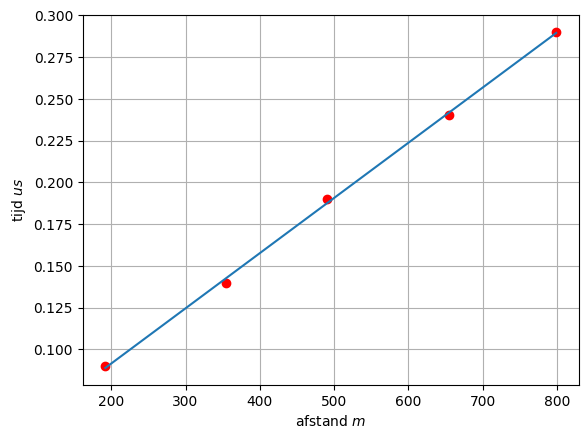

In [3]:
t = np.array([192, 355, 490, 654, 799])
x = (59 - np.array([50, 45, 40, 35, 30])) * 1e-2

def f(t, a, b):
    return a * t + b

def fit(t, x):
    #fit your function to the data
    popt, pcov = curve_fit(f, t, x, p0 = [330, 0])
    pcov = np.sqrt(np.diag(pcov))
    return popt

popt = fit(t, x)

# a is de geluidsnelheid m/us
#deze eenheden omdat het 
# b is de tijd die er nodig is als de sensor en meeter 0m uit elkaar zitten
a = popt[0]
b = popt[1]
print(a, b)

plt.figure()
plt.plot(t, x, 'ro')
plt.plot(t, f(t, *popt))
plt.xlabel(r"afstand $m$")
plt.ylabel(r"tijd $us$")

plt.grid()
plt.show()

## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr   R
0   0  40   0  30  43
1   0  30   0  20  44
2  40   0  30   0  44
3  30   0  20   0  44


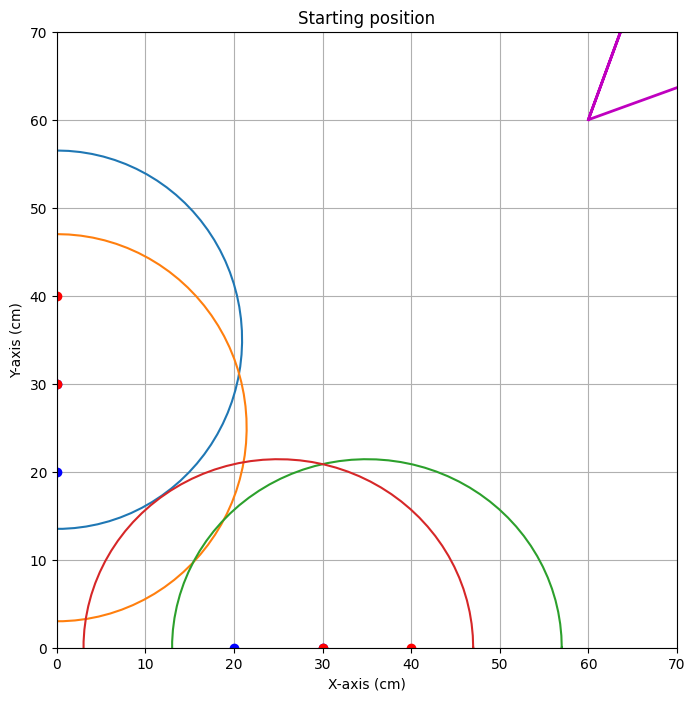


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=98.205


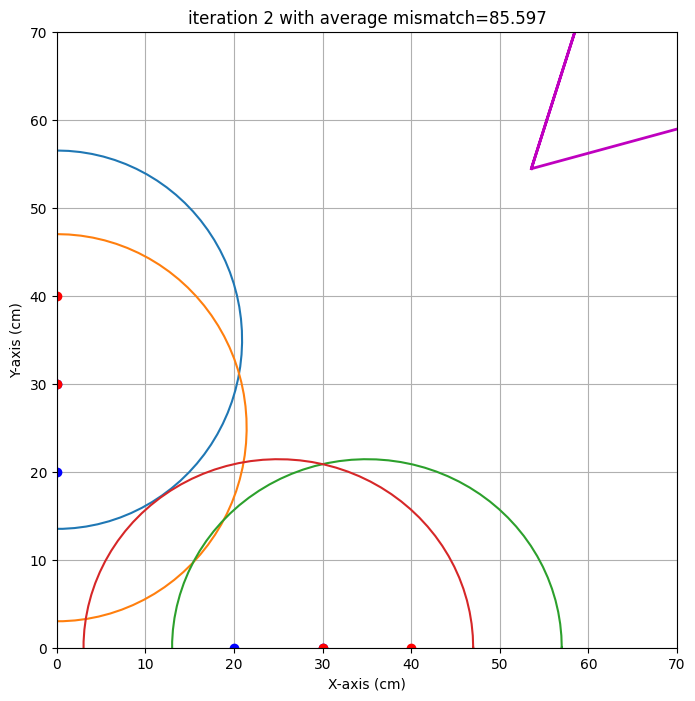

end iteration 2 with average mismatch=85.597


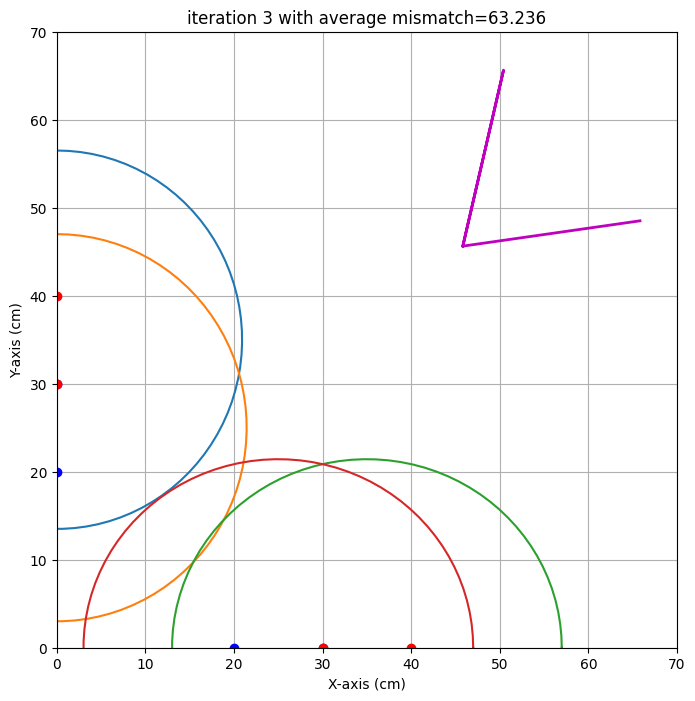

end iteration 3 with average mismatch=63.236


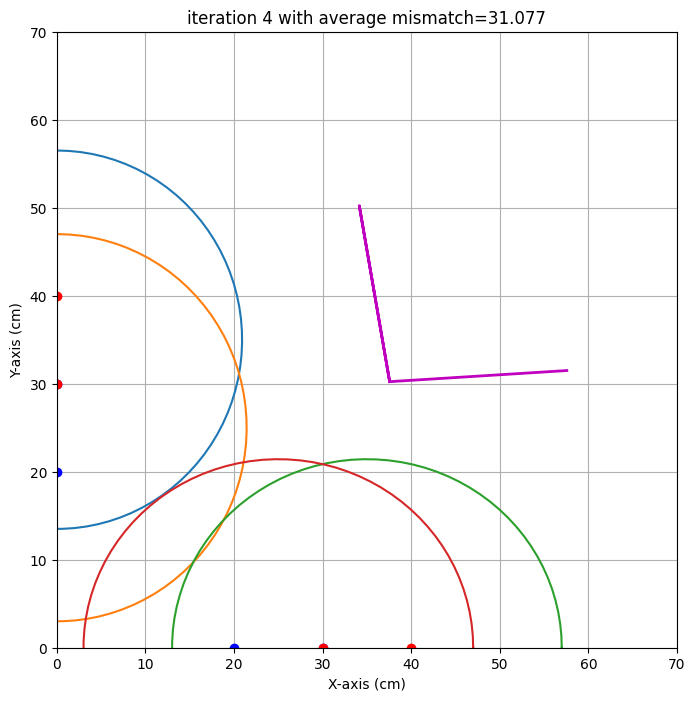

end iteration 4 with average mismatch=31.077


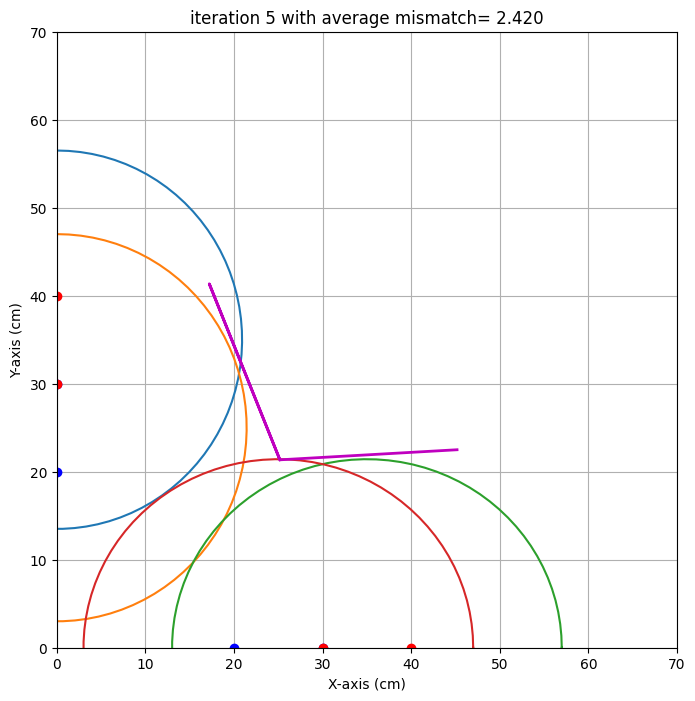

end iteration 5 with average mismatch= 2.420


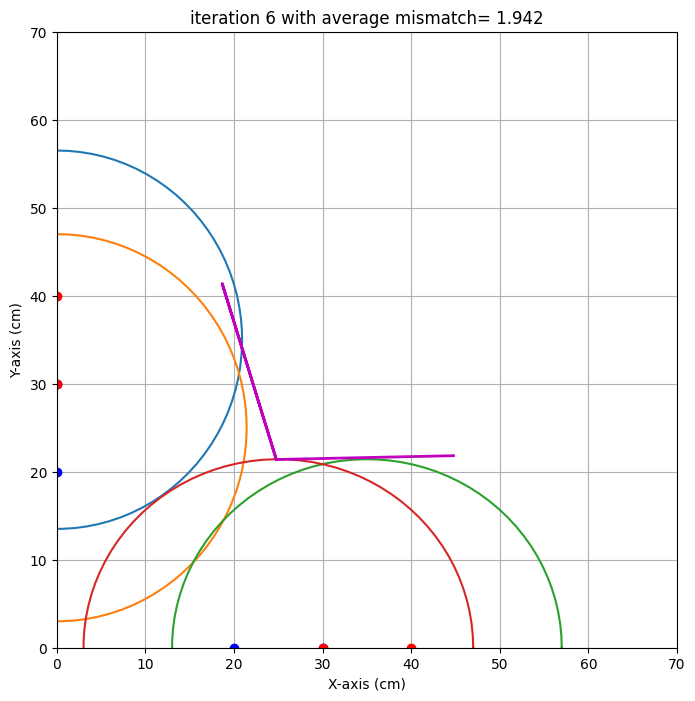

end iteration 6 with average mismatch= 1.942


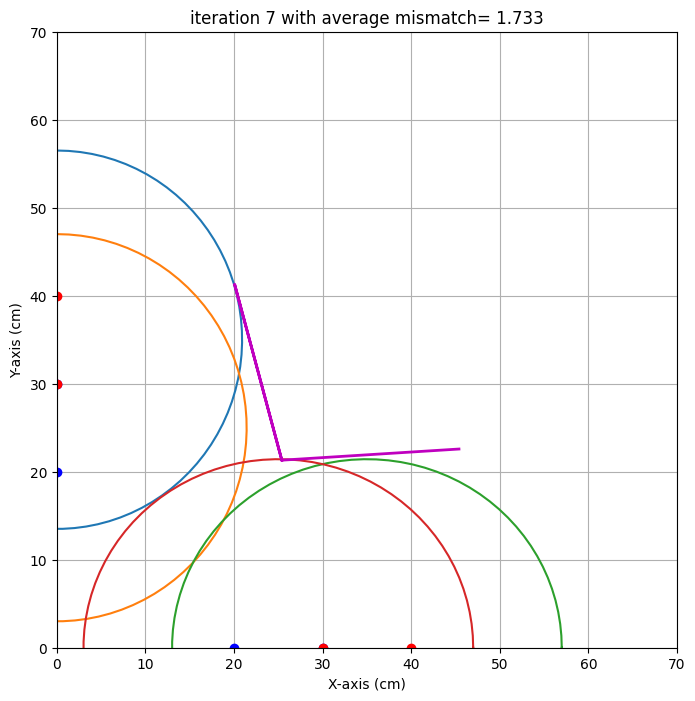

end iteration 7 with average mismatch= 1.733
end iteration 8 with average mismatch= 1.673


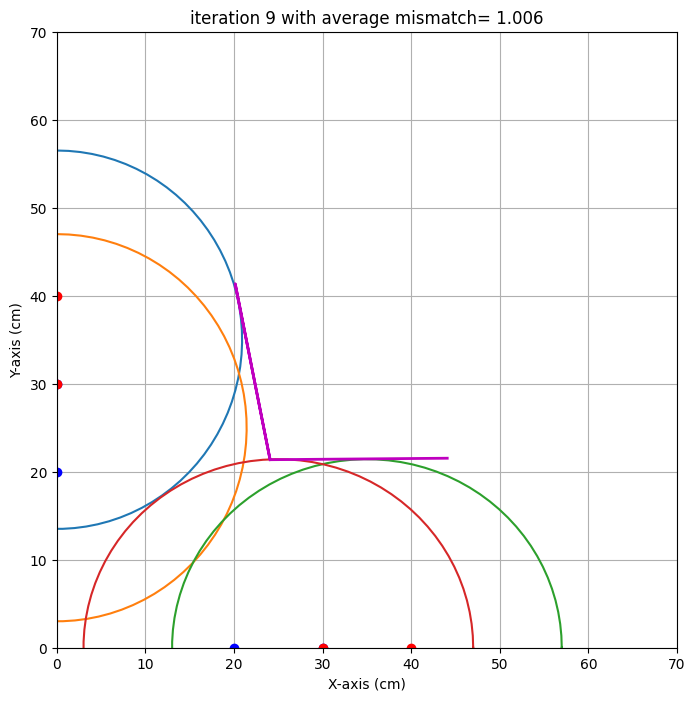

end iteration 9 with average mismatch= 1.006


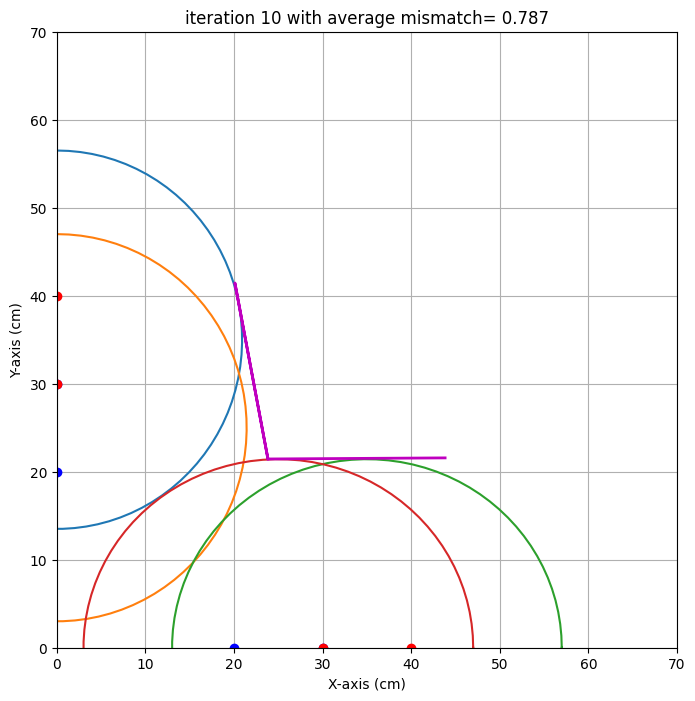

end iteration 10 with average mismatch= 0.787
end iteration 11 with average mismatch= 0.765
end iteration 12 with average mismatch= 0.707
end iteration 13 with average mismatch= 0.706
end iteration 14 with average mismatch= 0.706
end iteration 15 with average mismatch= 0.706


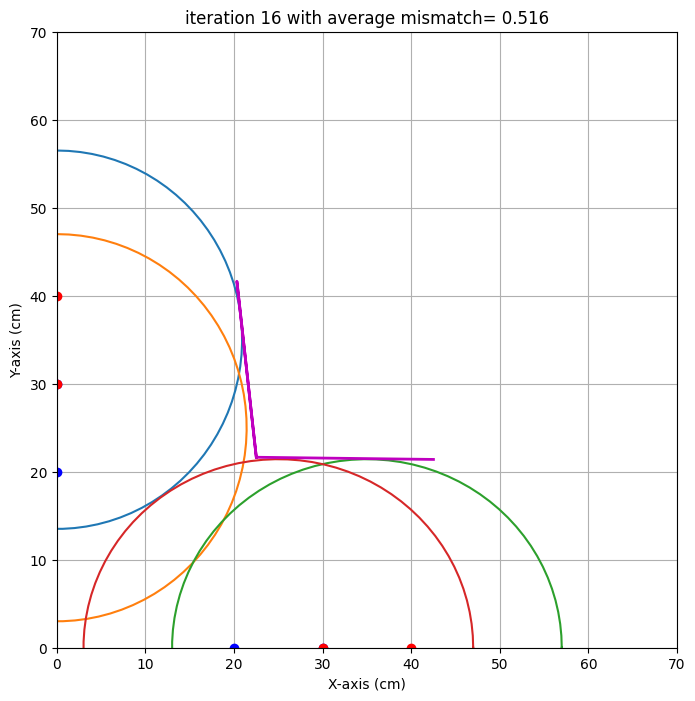

end iteration 16 with average mismatch= 0.516


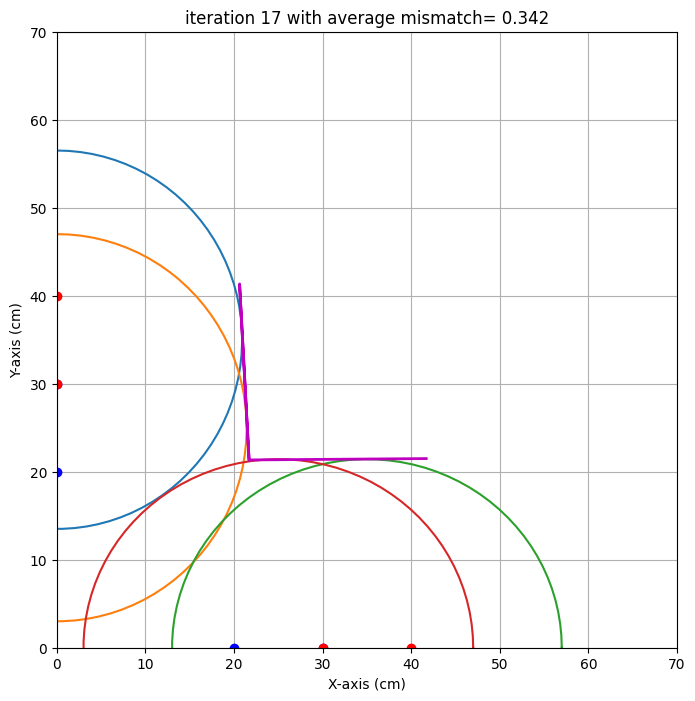

end iteration 17 with average mismatch= 0.342


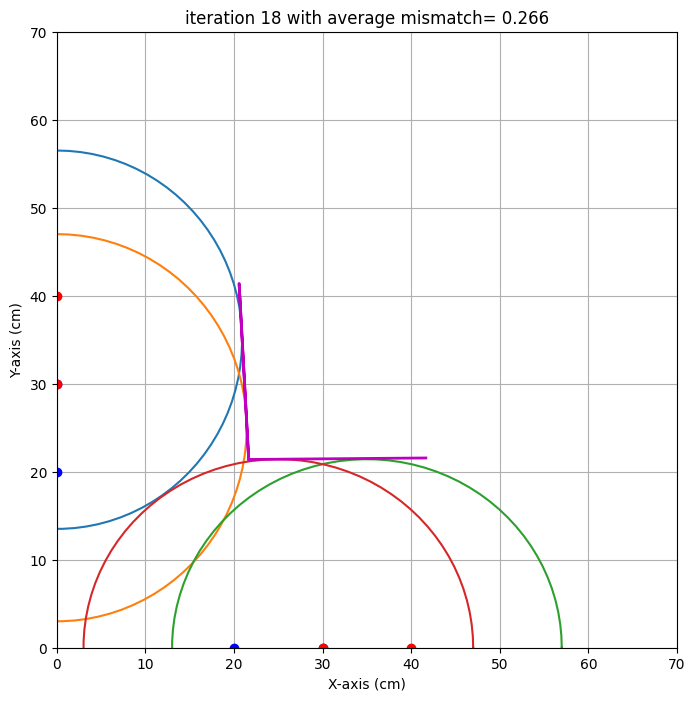

end iteration 18 with average mismatch= 0.266


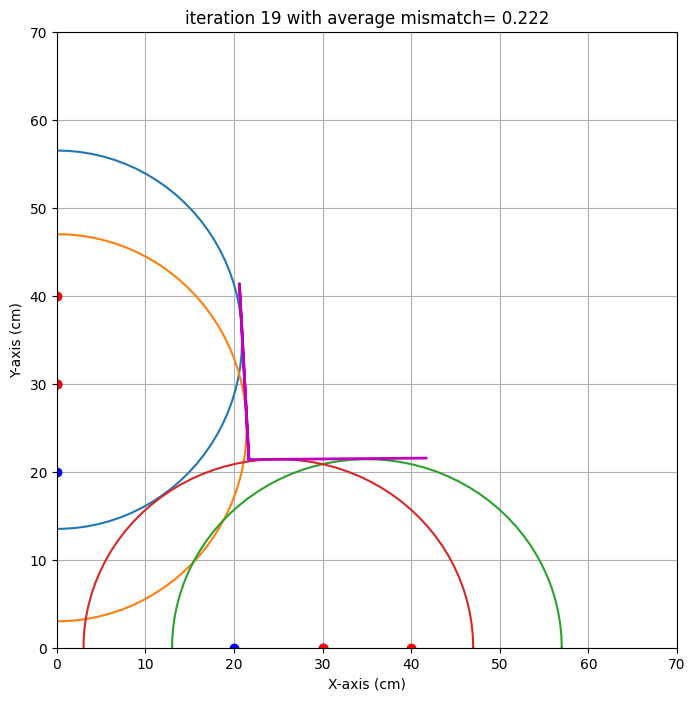

end iteration 19 with average mismatch= 0.222
end iteration 20 with average mismatch= 0.220
end iteration 21 with average mismatch= 0.220
end iteration 22 with average mismatch= 0.220
end iteration 23 with average mismatch= 0.220
end iteration 24 with average mismatch= 0.220
end iteration 25 with average mismatch= 0.220
end iteration 26 with average mismatch= 0.220
end iteration 27 with average mismatch= 0.216


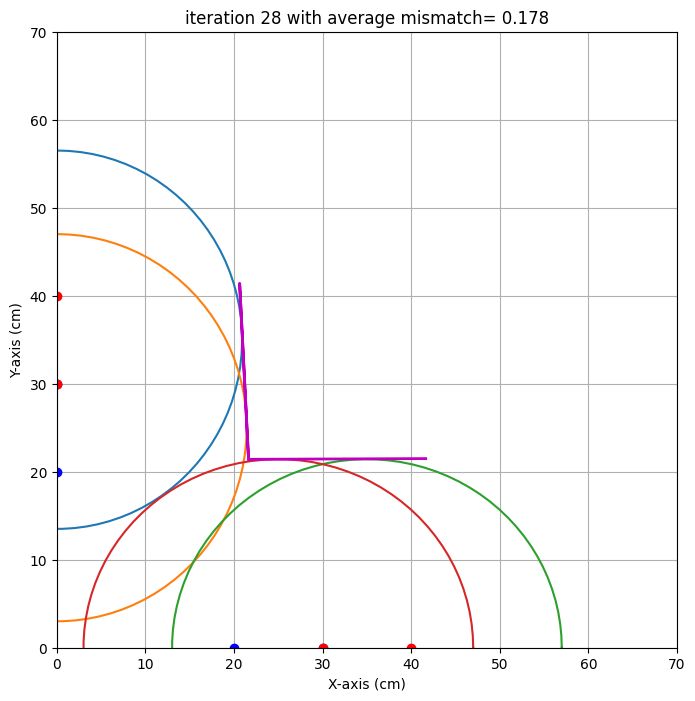

end iteration 28 with average mismatch= 0.178
end iteration 29 with average mismatch= 0.172
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.171
###############################################################################
end of iteration  30
Best alpha=   0.23 with uncertainty=   0.37
Best beta =  -2.89 with uncertainty=   1.11
Best x0   =  21.63 with uncertainty=   0.33
Best y0   =  21.40 with uncertainty=   0.20
###############################################################################


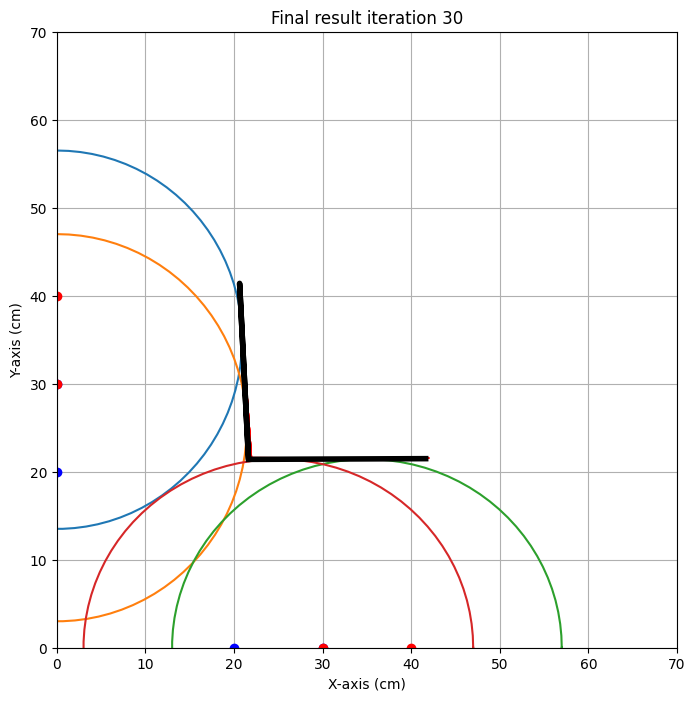

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30, 43],
    [0,30,0,20, 44],
#    [0,10,0,20, 244], hij ziet het papiertje niet maar de laptop
    [40,0,30,0, 44],
    [30,0,20,0, 44],
#    [10,0,20,0, 244], hij meet weer wat anders
#    [10,0,0,10, 256]  hij meet de hoek en niet een van de randen  
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 21.6 cm met een standaardafwijking van 0.3 cm 
y0: 21.4 cm met een standaardafwijking van 0.2 cm 
alpha: 0.2 graden met een standaardafwijking van 0.4 graad 
beta: -2.9 graden met een standaardafwijking van 1.1 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Bart]
1. start 

2. start met meetlocaties

eerste 4 "test locaties"
om te kijken waar hij ongeveer zit 

bron   , ontvanger
A [30, 0], [40, 0]
B [50, 0], [60, 0]
C [0, 30], [0, 40]
D [0, 50], [0, 60]

    # een meting is ongelding als deze groter dan 70cm of kleiner dan 20cm is

3. maak afhankelijk van welke metingen raakte een keuze voor de volgende metingen

	a (alle 4 raakte)
	 dit betekend dat hij ongeveer in het midden staat en er zijn in principe geen verdere metingen nodig om alles te bepalen


	b (2 raakte: 1 op elke as)
	 dit betekend dat hij in een van de 4 kwadranten zit
	doe 2 extra metingen (1 per as) en verplaats hiervoor alles met 5 richting 0
	in het geval dat een (of allebei)van deze waarde(s) niet geldig zijn verplaats je ze t.o.v hun beginposities 5 van 0 af
	nu zou je 4 goede metingen moeten hebben kan je alles bepalen 


	c (3 raken)
	 dit betekend dat hij in de buurt van een van de randen zit
	doe 1 extra meting op de as waarvan je maar een geldige metingen had en verplaats hiervoor alles met 5 richting 0
	in het geval dat deze waarde niet geldig IS verplaats je hem t.o.v zijn beginposities 5 van 0 af
	nu zou je 4 goede metingen moeten hebben kan je alles bepalen 

	d (1 raakt of 2 op dezelfde as)
	 dit betekend dat de hoek tussen het karton redelijk klein is
	 dit betekend dat hij zich bevind in een van de kolommen tussen of buiten de meetputen A,B,C,D 
	 afhankelijk van op welke as je de metingen had

	als je maar 1 raak is:
		voor de as van de waarde die wel raakte:
		doe 1 extra meting op de as waarvan je maar een geldige metingen had en verplaats hiervoor alles met 5 richting 0
		in het geval dat deze waarde niet geldig IS verplaats je hem t.o.v zijn beginposities 5 van 0 af
		nu zou je 4 goede metingen moeten hebben kan je alles bepalen


	voor de as waar je geen waardes had:
		probeer een van de volgende meetpunten afhankelijk van de as:
		x as
		[20,0],[30,0]
		[40,0],[50,0]
		[60,0],[70,0]
		y as
		[0,20],[0,30]
		[0,40],[0,50]
		[0,60],[0,70]
		
		als deze een raak is:
		doe 1 extra meting en verplaats alles met 5 richting 0
		in het geval dat deze waarde niet geldig is verplaats je hem t.o.v zijn beginposities 5 van 0 af
		nu zou je 4 goede metingen moeten hebben kan je alles bepalen

		als hij mis was:
		kies je een nieuw meetpunt tot i wel raak is

#### algoritme [Zahra]
<img src="Zahra2.jpeg" width="400">

#### algoritme [Shahraan]
<img src="Shahraan2.jpeg" width="400">

## Opdracht 6: Test iteratie 0.

In [6]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0': 33,
           'y0': -5,
           'alpha' :23.5,
           'beta' :33
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Zahra' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
#    [ 0, 10, 0, 20, 240], ongeldige meting
    [ 0, 30, 0, 20, 65],
    [ 0, 40, 0, 30, 65],
    [ 0, 50, 0, 40, 64],
#    [ 0, 60, 0, 50, 240], ongeldige meting
#    [ 0, 70, 0, 60, 240], ongeldige meting
#    [ 10, 0, 20, 0, 240], ongeldige meting
#    [ 30, 0, 20, 0, 240], ongeldige meting
#    [ 40, 0, 30, 0, 240], ongeldige meting
    [ 50, 0, 40, 0, 63],
    [ 60, 0, 50, 0, 68],
    [ 70, 0, 60, 0, 74]
    ]),
       'Bart' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
#    [ 30, 0, 40, 0, 240], ongeldige meting
    [ 50, 0, 60, 0, 67],
    [ 0, 30, 0, 40, 65],
#    [ 0, 50, 0, 60, 240], ongeldige meting
#    [ 25, 0, 35, 0, 240], ongeldige meting
    [ 35, 0, 45, 0, 58], # was iets bijgedraaid
    [ 0, 25, 0, 35, 68]
    ])
      }

## Opdracht 7: Evaluatie.

Bart
Running the imaging algorithm with the following data:
   xs  ys  xr  yr   R
0  50   0  60   0  67
1   0  30   0  40  65
2  35   0  45   0  58
3   0  25   0  35  68


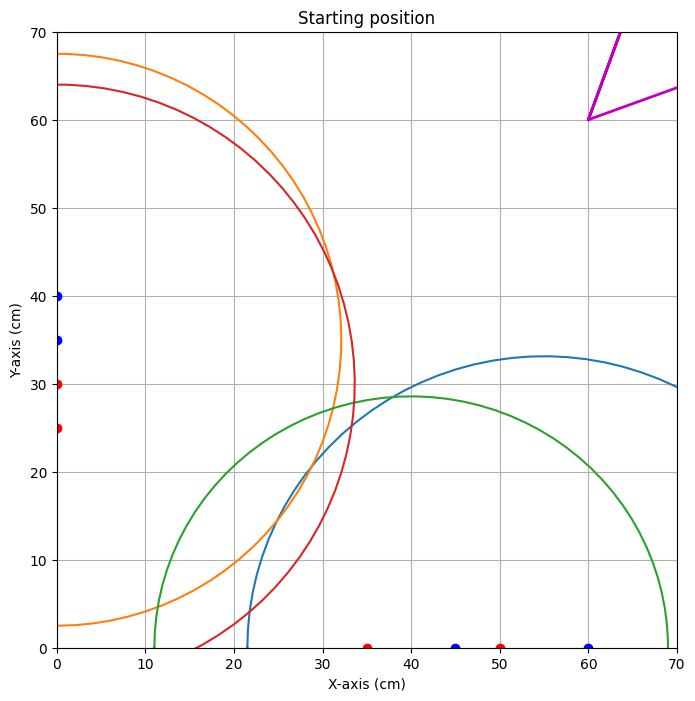


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=70.801


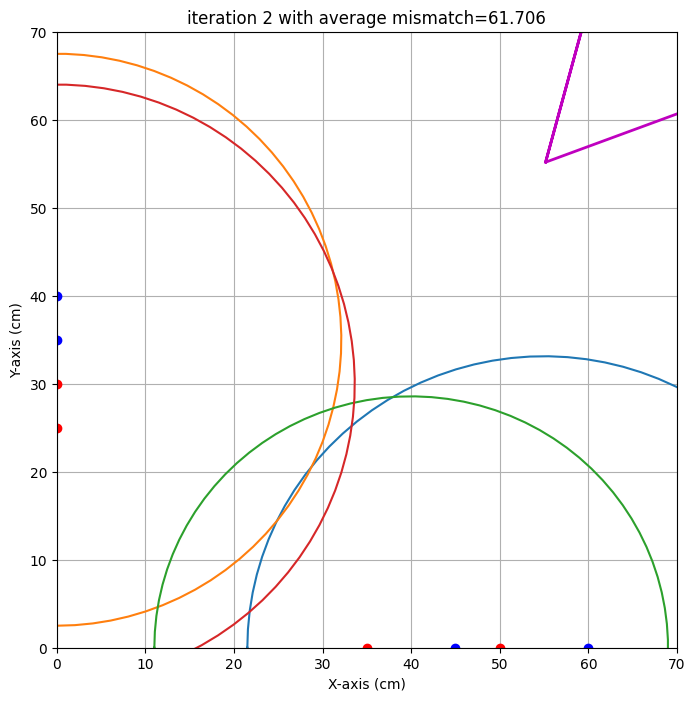

end iteration 2 with average mismatch=61.706


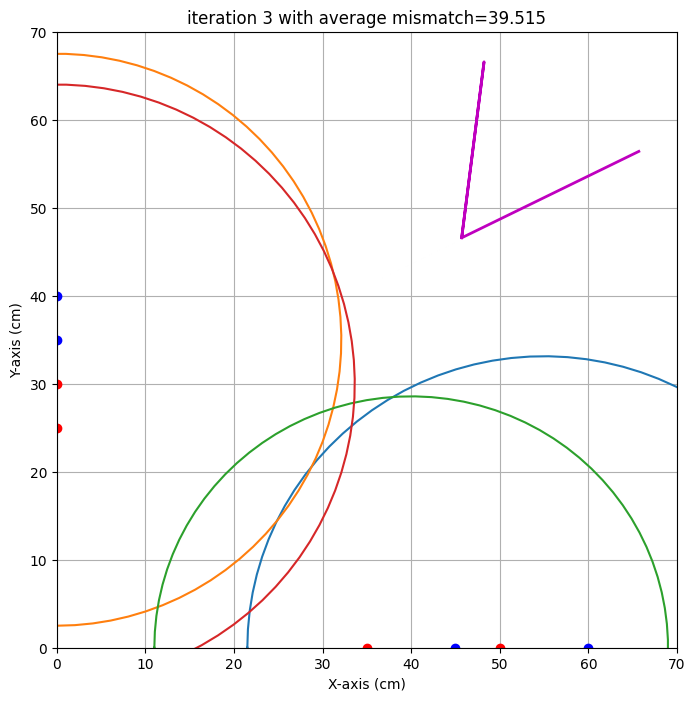

end iteration 3 with average mismatch=39.515


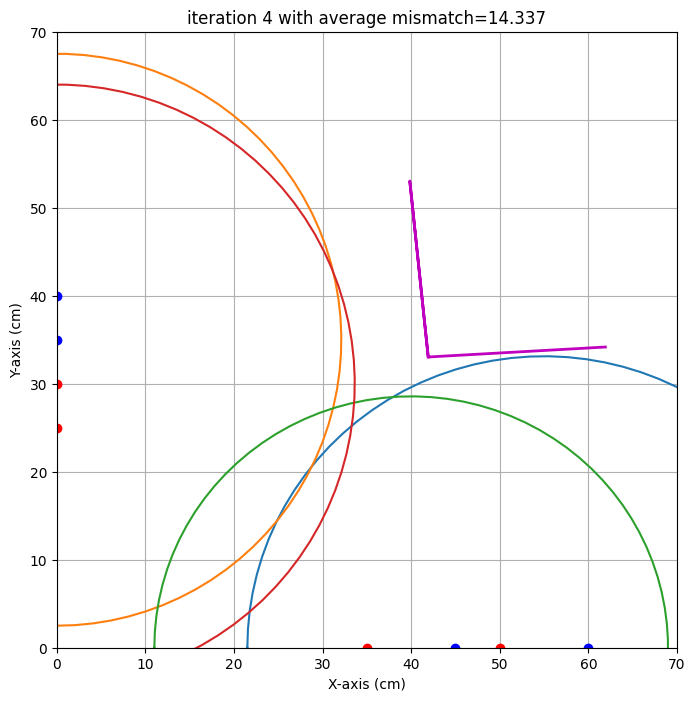

end iteration 4 with average mismatch=14.337


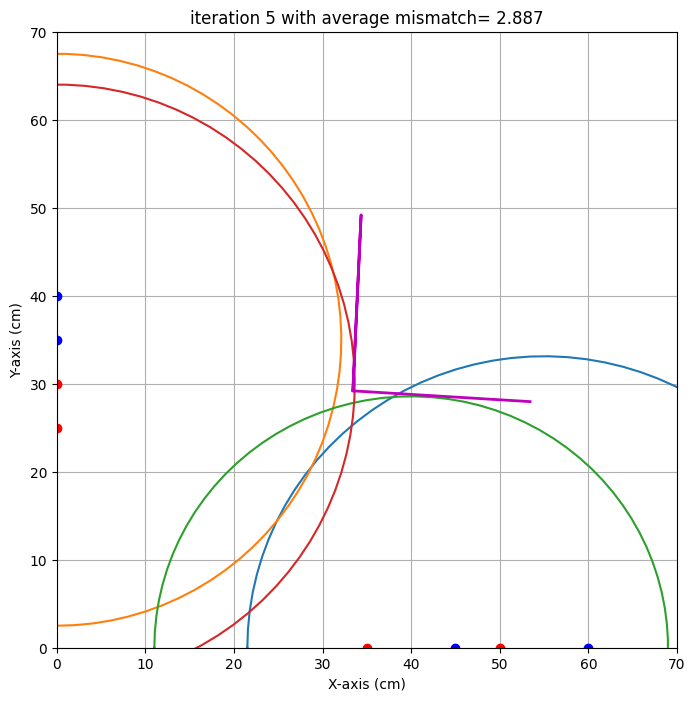

end iteration 5 with average mismatch= 2.887


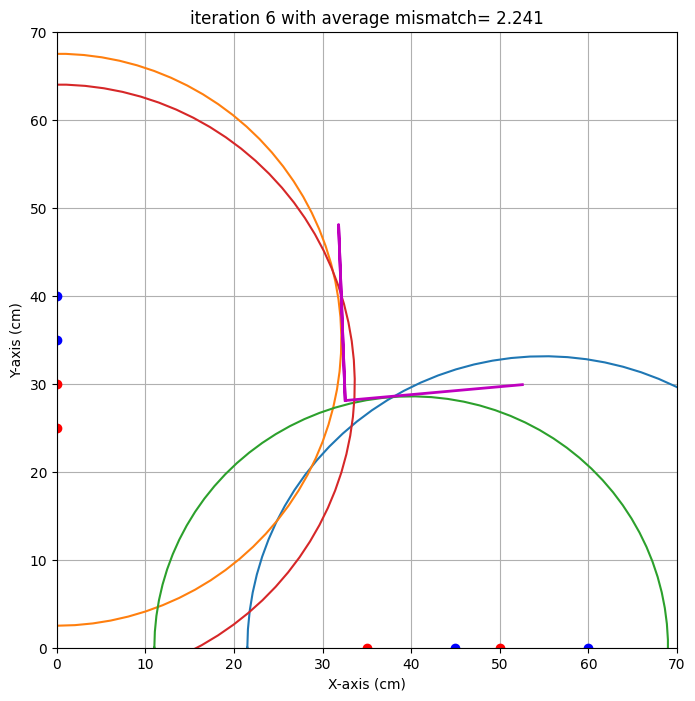

end iteration 6 with average mismatch= 2.241


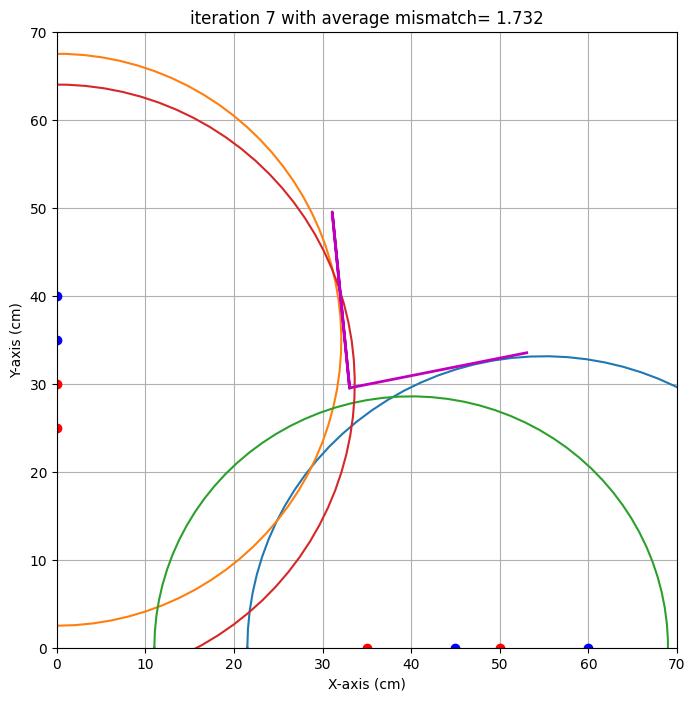

end iteration 7 with average mismatch= 1.732
end iteration 8 with average mismatch= 1.726
end iteration 9 with average mismatch= 1.573
end iteration 10 with average mismatch= 1.570
end iteration 11 with average mismatch= 1.544
end iteration 12 with average mismatch= 1.535
end iteration 13 with average mismatch= 1.531
end iteration 14 with average mismatch= 1.531
end iteration 15 with average mismatch= 1.531
end iteration 16 with average mismatch= 1.531
end iteration 17 with average mismatch= 1.531
end iteration 18 with average mismatch= 1.531
end iteration 19 with average mismatch= 1.531
end iteration 20 with average mismatch= 1.531
end iteration 21 with average mismatch= 1.531
end iteration 22 with average mismatch= 1.531
end iteration 23 with average mismatch= 1.531
end iteration 24 with average mismatch= 1.531
end iteration 25 with average mismatch= 1.531
end iteration 26 with average mismatch= 1.531
end iteration 27 with average mismatch= 1.531
end iteration 28 with average mismatc

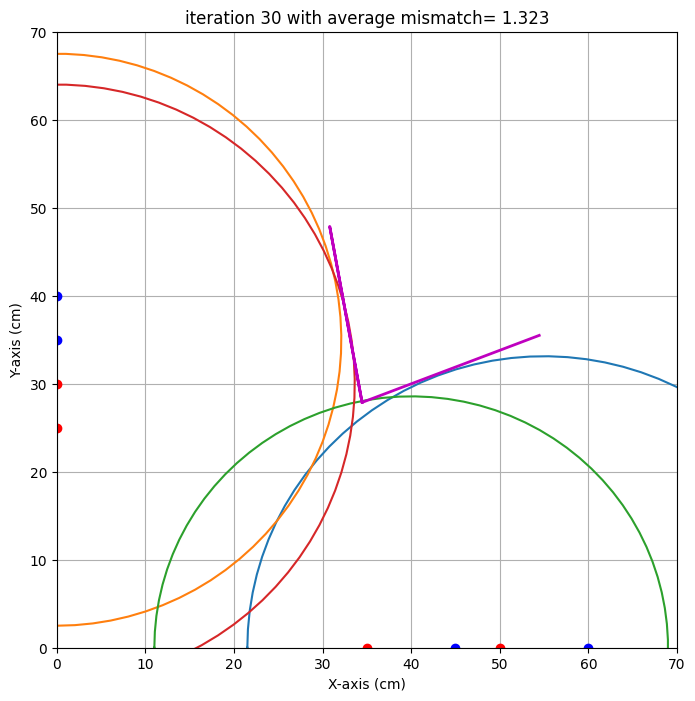

end iteration 30 with average mismatch= 1.323
###############################################################################
end of iteration  30
Best alpha=  20.85 with uncertainty=   3.81
Best beta = -10.35 with uncertainty=  12.24
Best x0   =  34.45 with uncertainty=   2.23
Best y0   =  27.88 with uncertainty=   0.47
###############################################################################


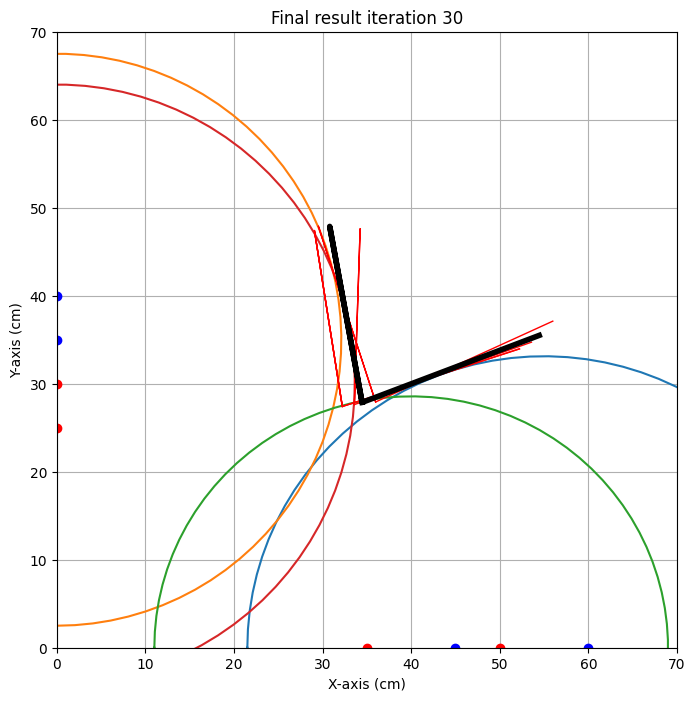

{'alpha': np.float64(20.846688659739947), 'alpha_eps': np.float64(3.812452027077356), 'beta': np.float64(-10.353048445650025), 'beta_eps': np.float64(12.239823526411872), 'x0': np.float64(34.45413629229139), 'x0_eps': np.float64(2.2283419561936455), 'y0': np.float64(27.87642312228553), 'y0_eps': np.float64(0.4668504556347095)}
Zahra
Running the imaging algorithm with the following data:
   xs  ys  xr  yr   R
0   0  30   0  20  65
1   0  40   0  30  65
2   0  50   0  40  64
3  50   0  40   0  63
4  60   0  50   0  68
5  70   0  60   0  74


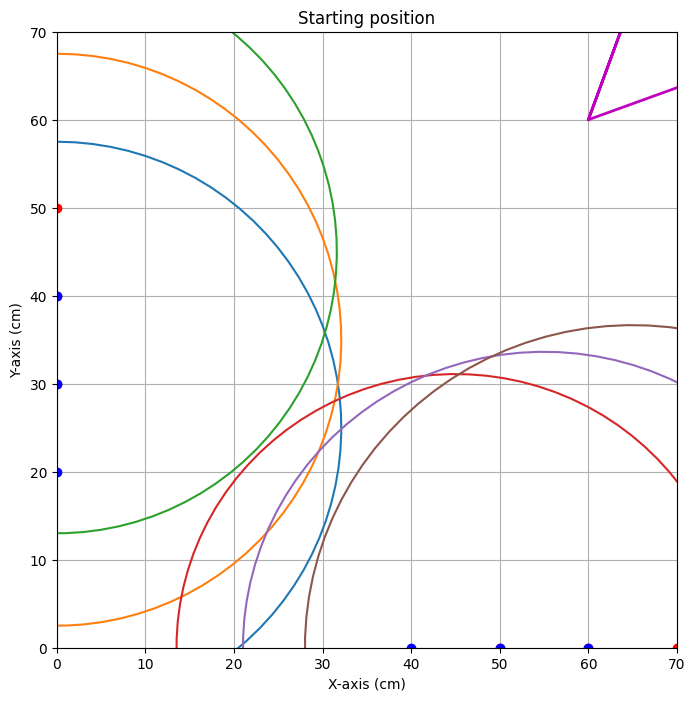


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=67.011


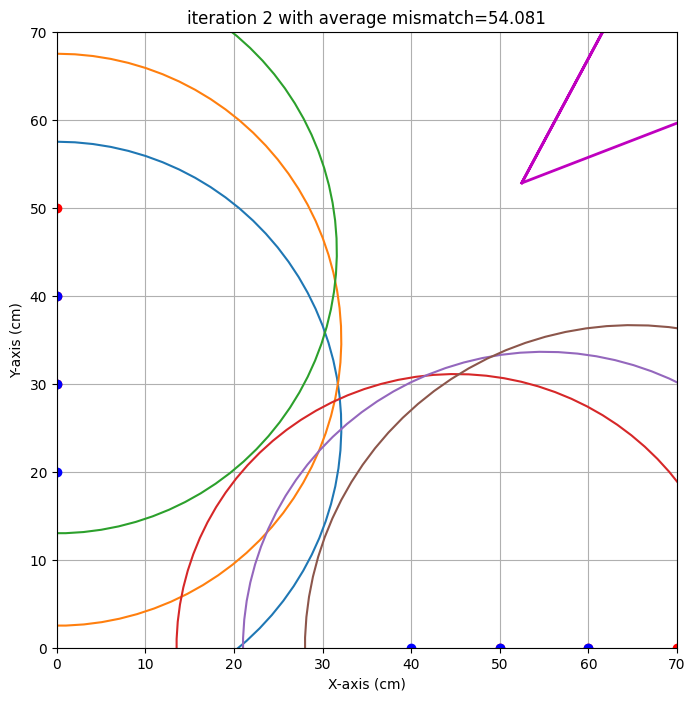

end iteration 2 with average mismatch=54.081


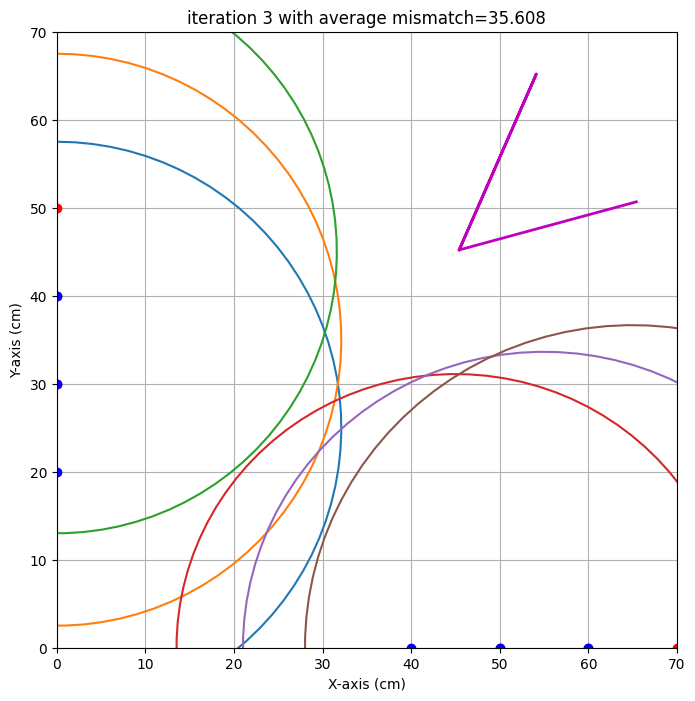

end iteration 3 with average mismatch=35.608


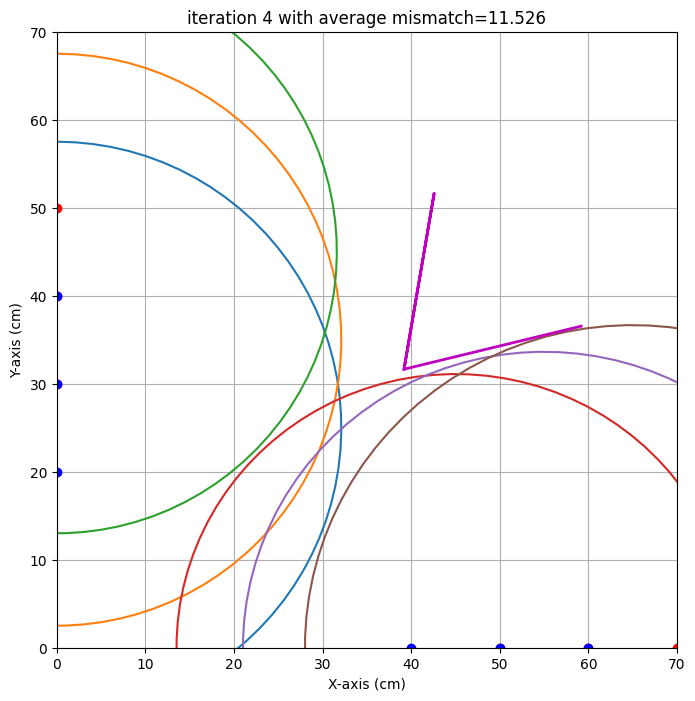

end iteration 4 with average mismatch=11.526


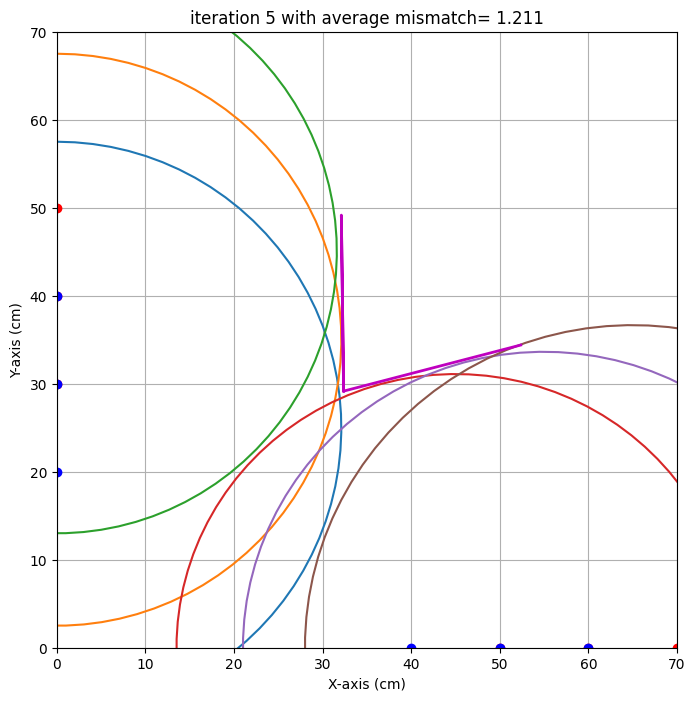

end iteration 5 with average mismatch= 1.211


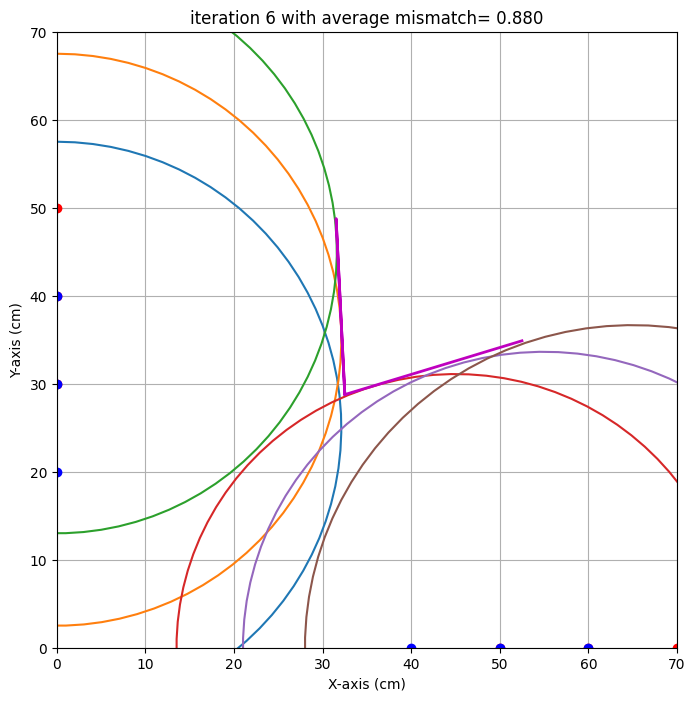

end iteration 6 with average mismatch= 0.880
end iteration 7 with average mismatch= 0.872
end iteration 8 with average mismatch= 0.872
end iteration 9 with average mismatch= 0.872
end iteration 10 with average mismatch= 0.872
end iteration 11 with average mismatch= 0.872
end iteration 12 with average mismatch= 0.872
end iteration 13 with average mismatch= 0.872
end iteration 14 with average mismatch= 0.872
end iteration 15 with average mismatch= 0.872
end iteration 16 with average mismatch= 0.872
end iteration 17 with average mismatch= 0.872
end iteration 18 with average mismatch= 0.813
end iteration 19 with average mismatch= 0.765
end iteration 20 with average mismatch= 0.753
end iteration 21 with average mismatch= 0.749
end iteration 22 with average mismatch= 0.749
end iteration 23 with average mismatch= 0.749
end iteration 24 with average mismatch= 0.749
end iteration 25 with average mismatch= 0.749
end iteration 26 with average mismatch= 0.749
end iteration 27 with average mismatch

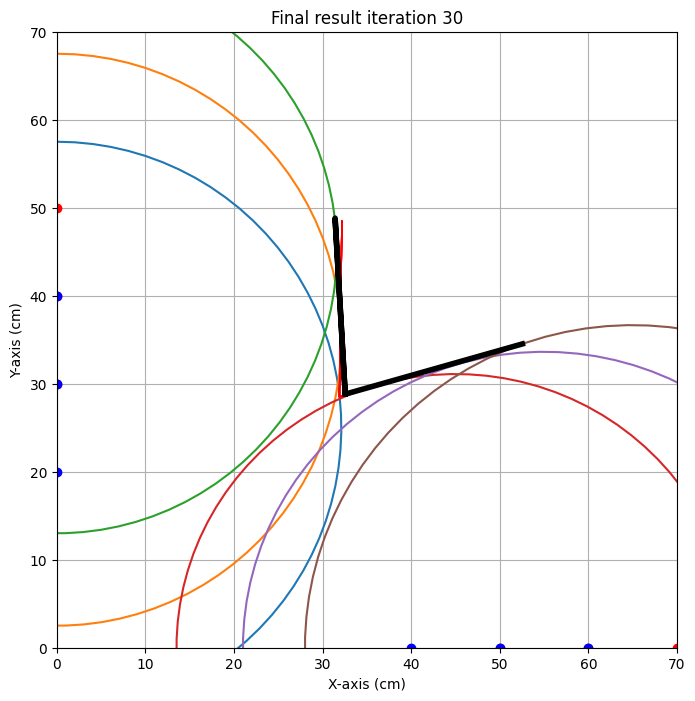

{'alpha': np.float64(15.919926915939625), 'alpha_eps': np.float64(0.3947839738072556), 'beta': np.float64(-3.2759194917822483), 'beta_eps': np.float64(4.070396454823194), 'x0': np.float64(32.550942997559495), 'x0_eps': np.float64(0.6514485789742324), 'y0': np.float64(28.816411839217455), 'y0_eps': np.float64(0.29901300250348584)}


In [7]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames[:-1]:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [8]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames[:-1]:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Bart 
x0 target is : 33.0. Gevonden waarde: 34.5 cm met een standaardafwijking van 2.2 cm 
y0 target is : -5.0. Gevonden waarde: 27.9 cm met een standaardafwijking van 0.5 cm 
alpha target is : 23.5. Gevonden waarde: 20.8 graden met een standaardafwijking van 3.8 graad 
beta target is : 33.0. Gevonden waarde: -10.4 graden met een standaardafwijking van 12.2 graad 

Zahra 
x0 target is : 33.0. Gevonden waarde: 32.6 cm met een standaardafwijking van 0.7 cm 
y0 target is : -5.0. Gevonden waarde: 28.8 cm met een standaardafwijking van 0.3 cm 
alpha target is : 23.5. Gevonden waarde: 15.9 graden met een standaardafwijking van 0.4 graad 
beta target is : 33.0. Gevonden waarde: -3.3 graden met een standaardafwijking van 4.1 graad 



## Opdracht 8: Iteratie1+.V 14:50
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](ideratie_1.png)


## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr   R
0  30   0  40   0  91
1  50   0  60   0  89
2   0  50   0  60  72
3   0  42   0  57  77


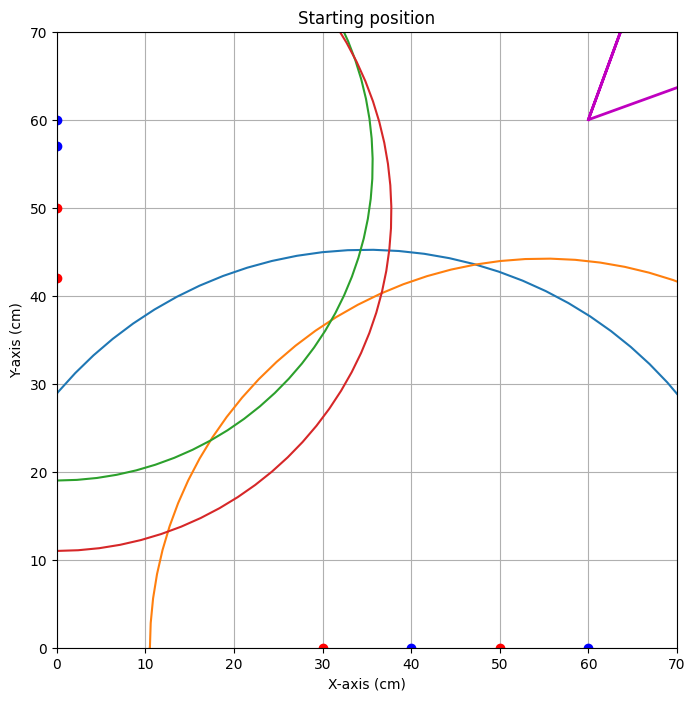


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=47.343


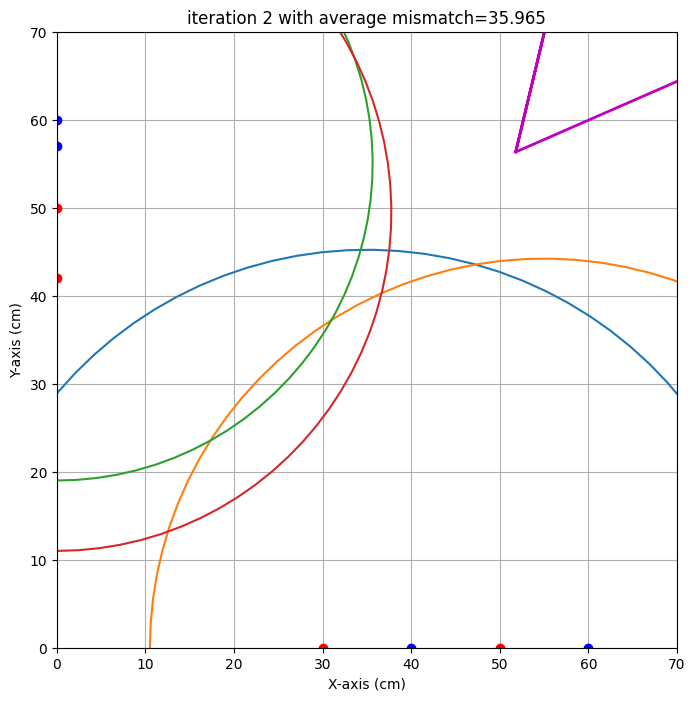

end iteration 2 with average mismatch=35.965


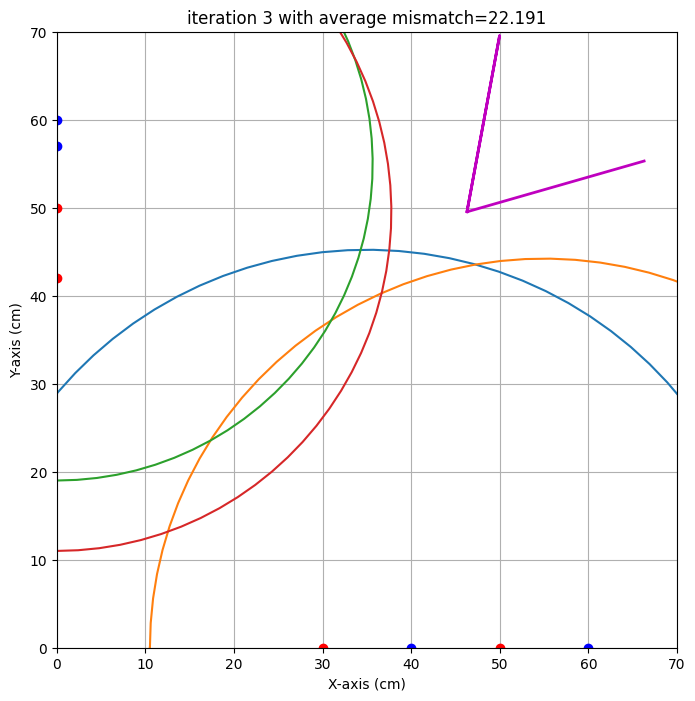

end iteration 3 with average mismatch=22.191


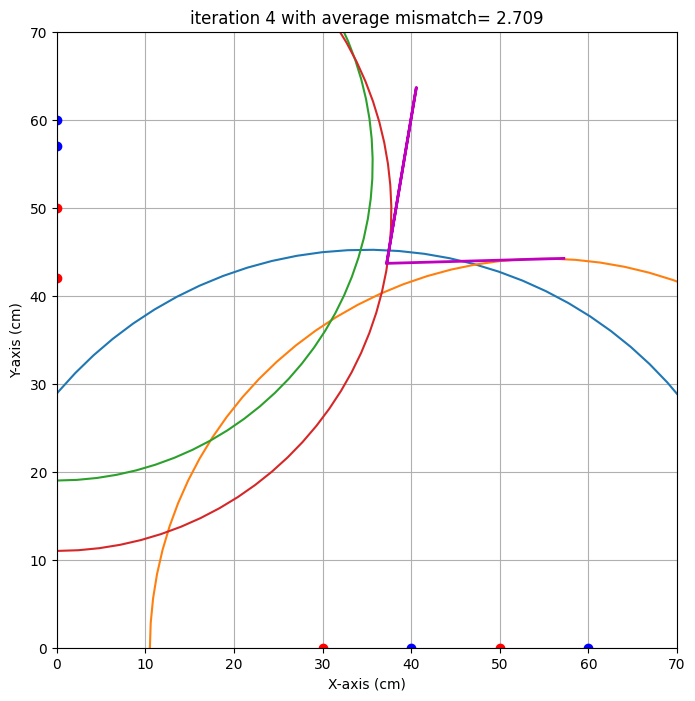

end iteration 4 with average mismatch= 2.709


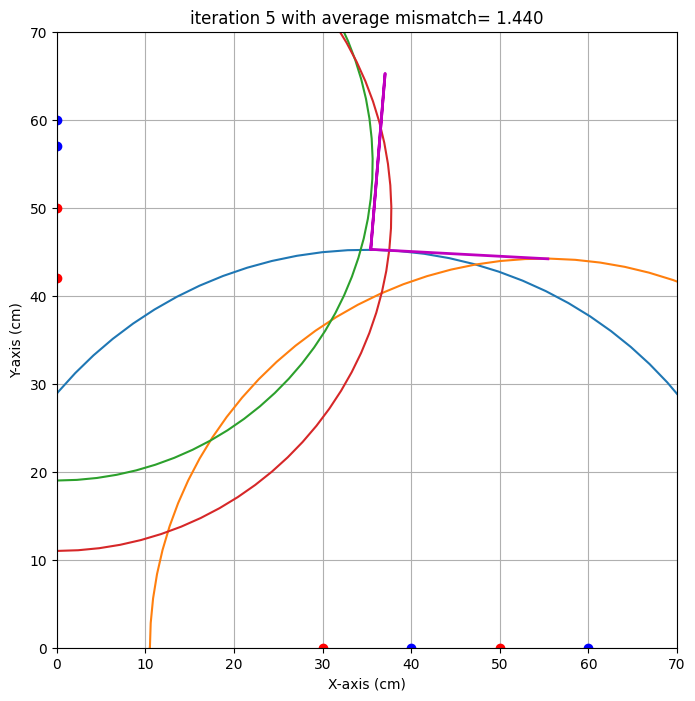

end iteration 5 with average mismatch= 1.440
end iteration 6 with average mismatch= 1.406
end iteration 7 with average mismatch= 1.405
end iteration 8 with average mismatch= 1.361
end iteration 9 with average mismatch= 1.340
end iteration 10 with average mismatch= 1.340
end iteration 11 with average mismatch= 1.340
end iteration 12 with average mismatch= 1.340
end iteration 13 with average mismatch= 1.340
end iteration 14 with average mismatch= 1.340
end iteration 15 with average mismatch= 1.340
end iteration 16 with average mismatch= 1.340
end iteration 17 with average mismatch= 1.340
end iteration 18 with average mismatch= 1.340
end iteration 19 with average mismatch= 1.340
end iteration 20 with average mismatch= 1.340
end iteration 21 with average mismatch= 1.340
end iteration 22 with average mismatch= 1.340
end iteration 23 with average mismatch= 1.340
end iteration 24 with average mismatch= 1.321
end iteration 25 with average mismatch= 1.316
end iteration 26 with average mismatch=

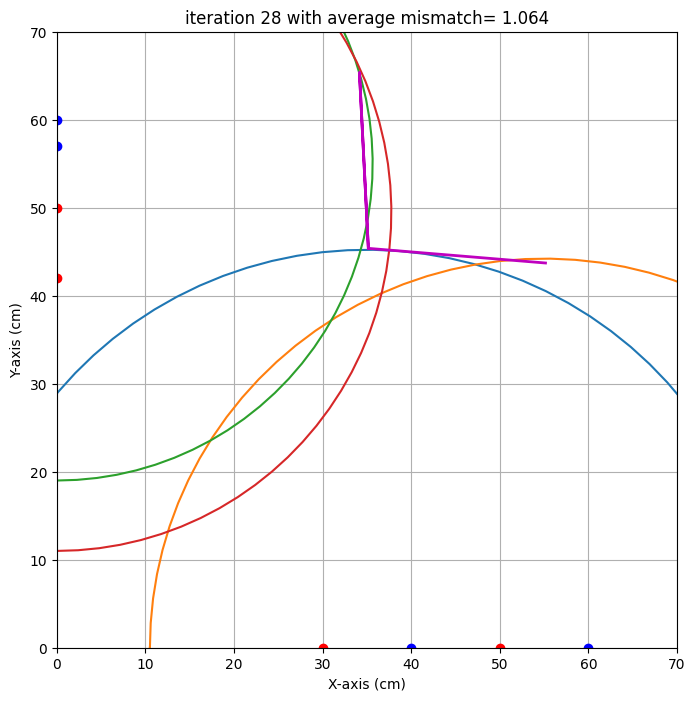

end iteration 28 with average mismatch= 1.064


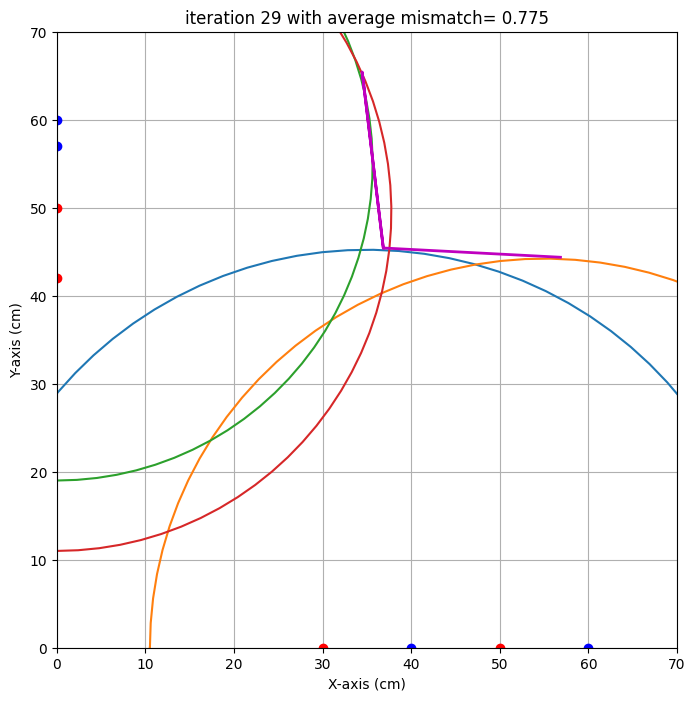

end iteration 29 with average mismatch= 0.775
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....


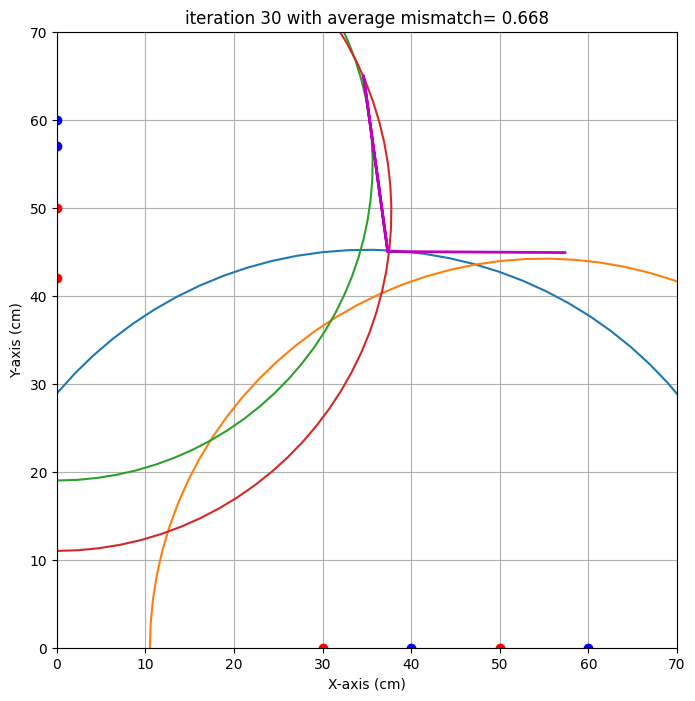

end iteration 30 with average mismatch= 0.668
###############################################################################
end of iteration  30
Best alpha=  -0.33 with uncertainty=   3.66
Best beta =  -7.81 with uncertainty=   4.20
Best x0   =  37.35 with uncertainty=   1.99
Best y0   =  45.02 with uncertainty=   0.62
###############################################################################


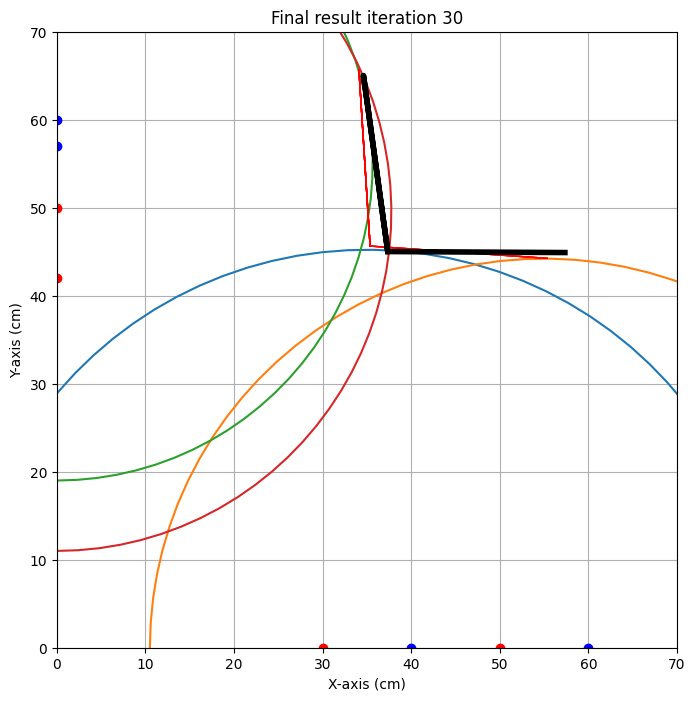

{'alpha': np.float64(-0.32512469418950785), 'alpha_eps': np.float64(3.661826238642191), 'beta': np.float64(-7.805501530869066), 'beta_eps': np.float64(4.200242319302765), 'x0': np.float64(37.35459534474285), 'x0_eps': np.float64(1.9939987815138949), 'y0': np.float64(45.01881336147209), 'y0_eps': np.float64(0.6224585932681777)}
locatie 1 
x0 target is : 33.4. Gevonden waarde: 37.4 cm met een standaardafwijking van 2.0 cm 
y0 target is : 43.9. Gevonden waarde: 45.0 cm met een standaardafwijking van 0.6 cm 
alpha target is : 18.0. Gevonden waarde: -0.3 graden met een standaardafwijking van 3.7 graad 
beta target is : 0.0. Gevonden waarde: -7.8 graden met een standaardafwijking van 4.2 graad 



In [9]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0': 33.4,
                    'y0': 43.9,
                    'alpha' : 18,
                    'beta' : 0},
            }


# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [ 30, 0, 40, 0, 91],
    [ 50, 0, 60, 0, 89],
#    [ 0, 30, 0, 40, 240], ongeldige meting
    [ 0, 50, 0, 60, 72],
#    [ 0, 40, 0, 50, ]
    [ 0, 42, 0, 57, 77] #afgeweken val algoritme om hem te verbeteren 
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

# iteratie 2

Figuur: ![Alt](ideratie_2.png)

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr   R
0  30   0  45   0  59
1   0  30   0  45  54
2  40   0  55   0  60
3   0  40   0  55  57


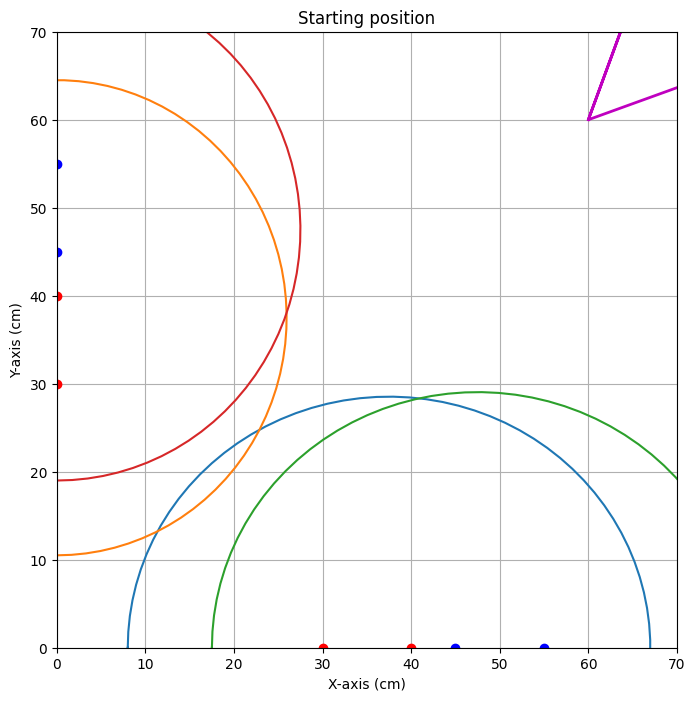


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=75.277


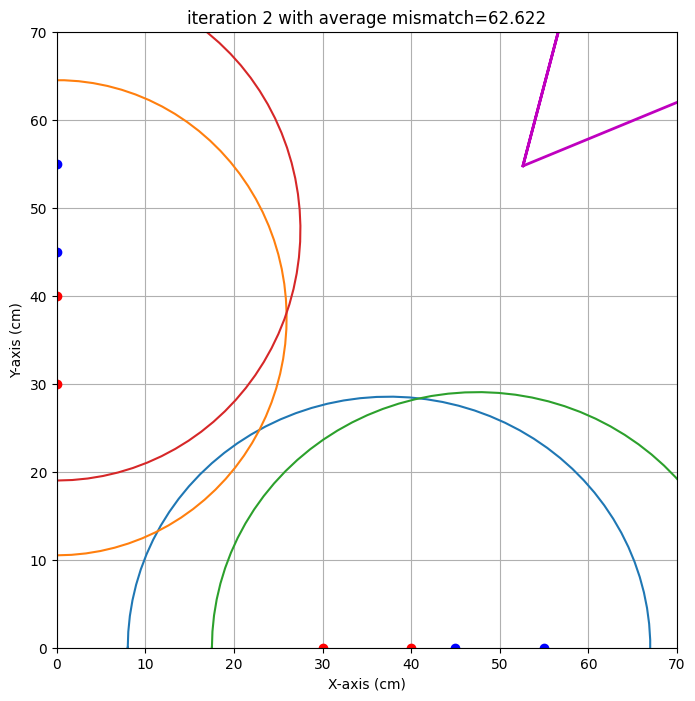

end iteration 2 with average mismatch=62.622


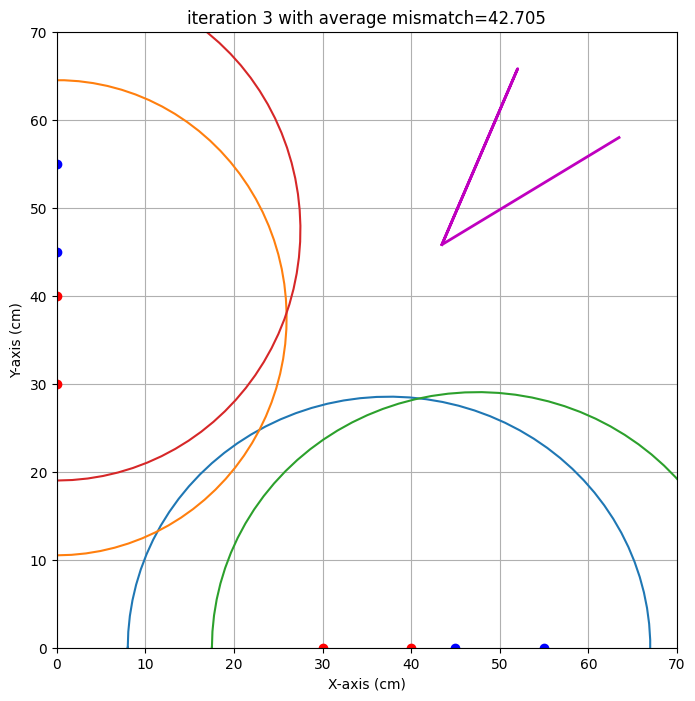

end iteration 3 with average mismatch=42.705


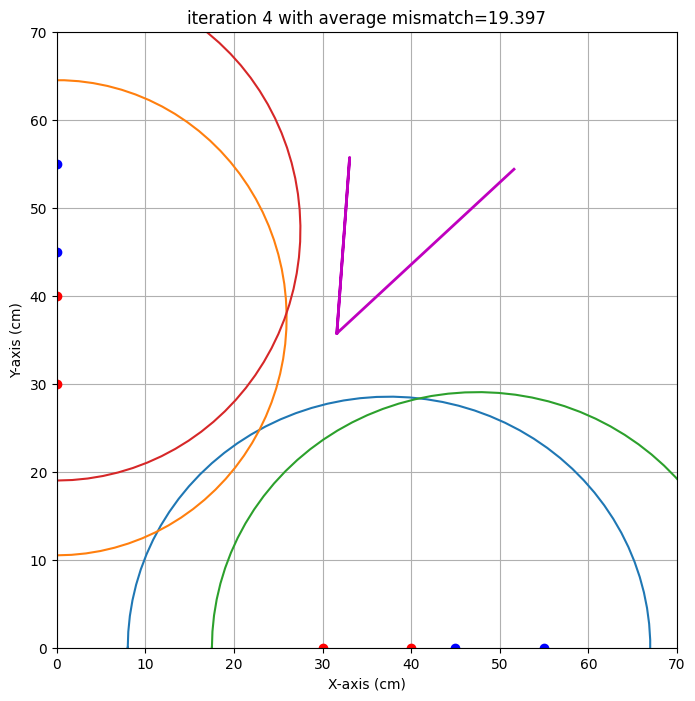

end iteration 4 with average mismatch=19.397


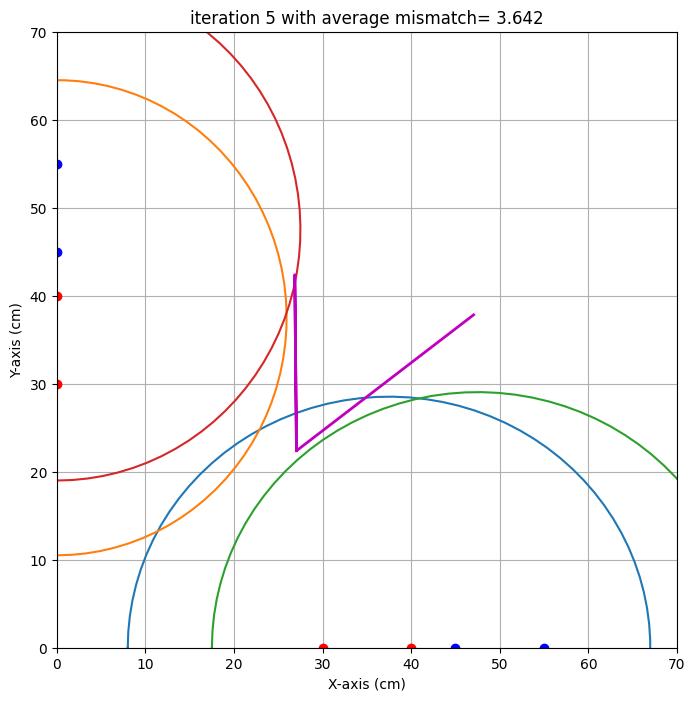

end iteration 5 with average mismatch= 3.642


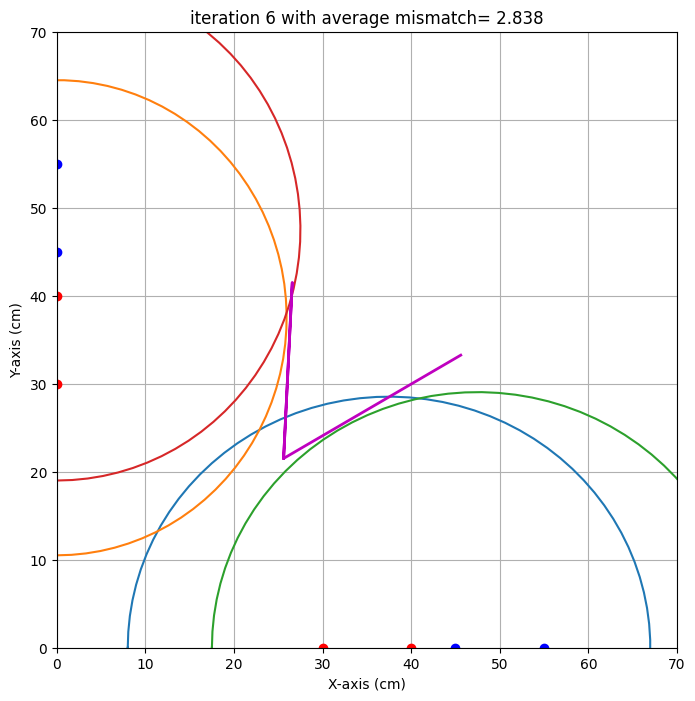

end iteration 6 with average mismatch= 2.838
end iteration 7 with average mismatch= 2.697


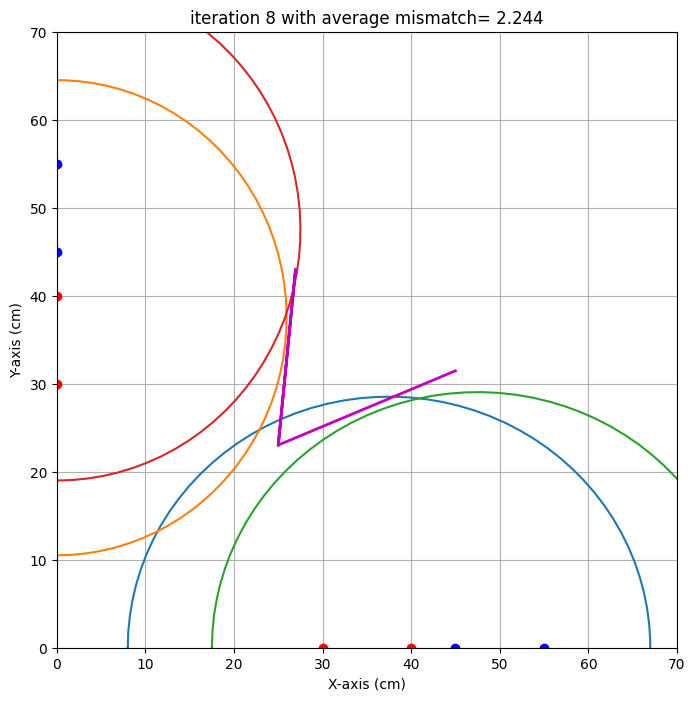

end iteration 8 with average mismatch= 2.244


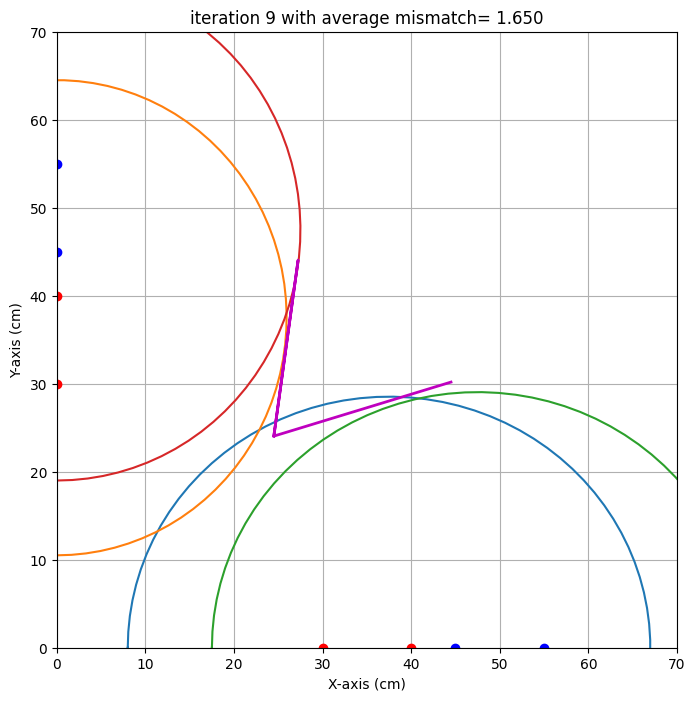

end iteration 9 with average mismatch= 1.650
end iteration 10 with average mismatch= 1.515
end iteration 11 with average mismatch= 1.393
end iteration 12 with average mismatch= 1.365
end iteration 13 with average mismatch= 1.241
end iteration 14 with average mismatch= 1.201
end iteration 15 with average mismatch= 1.197
end iteration 16 with average mismatch= 1.197
end iteration 17 with average mismatch= 1.197
end iteration 18 with average mismatch= 1.197
end iteration 19 with average mismatch= 1.197
end iteration 20 with average mismatch= 1.197
end iteration 21 with average mismatch= 1.197
end iteration 22 with average mismatch= 1.197
end iteration 23 with average mismatch= 1.197
end iteration 24 with average mismatch= 1.197
end iteration 25 with average mismatch= 1.197
end iteration 26 with average mismatch= 1.092


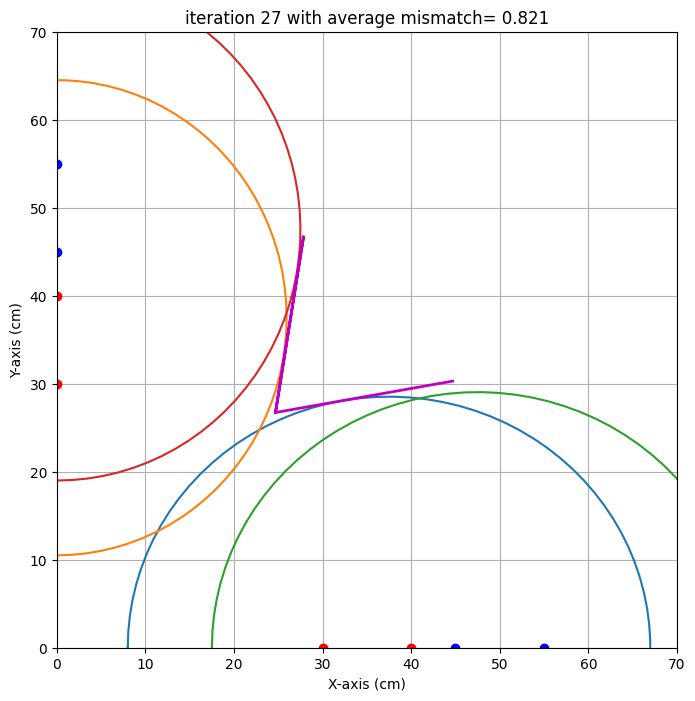

end iteration 27 with average mismatch= 0.821
end iteration 28 with average mismatch= 0.793


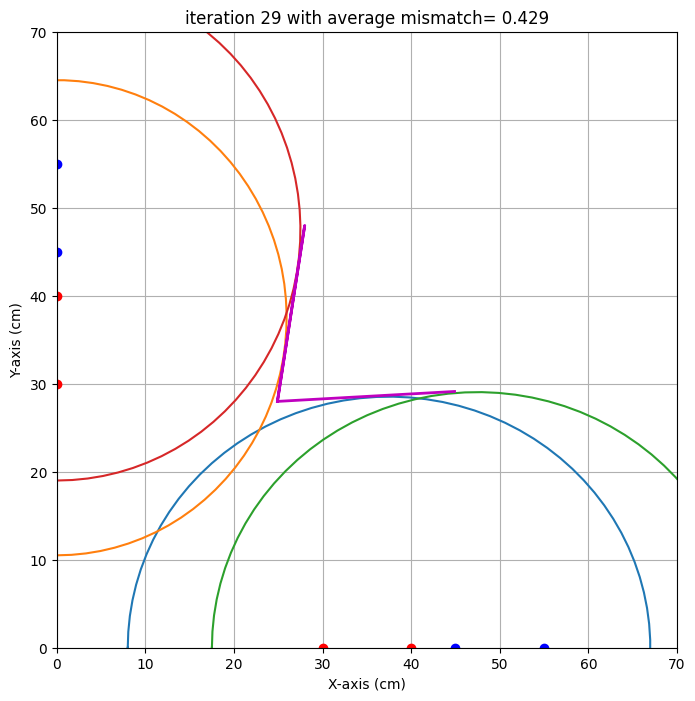

end iteration 29 with average mismatch= 0.429
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....


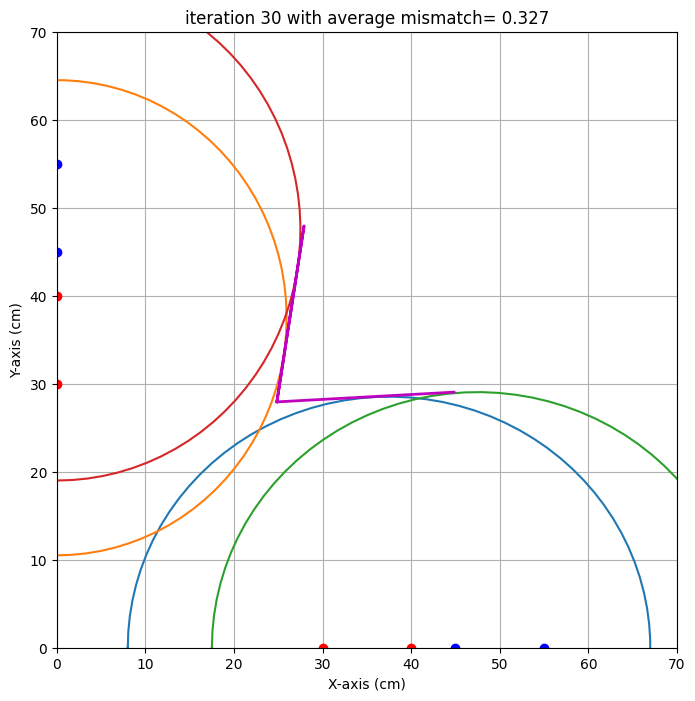

end iteration 30 with average mismatch= 0.327
###############################################################################
end of iteration  30
Best alpha=   3.17 with uncertainty=   2.43
Best beta =   8.72 with uncertainty=   0.84
Best x0   =  24.84 with uncertainty=   0.11
Best y0   =  27.93 with uncertainty=   0.43
###############################################################################


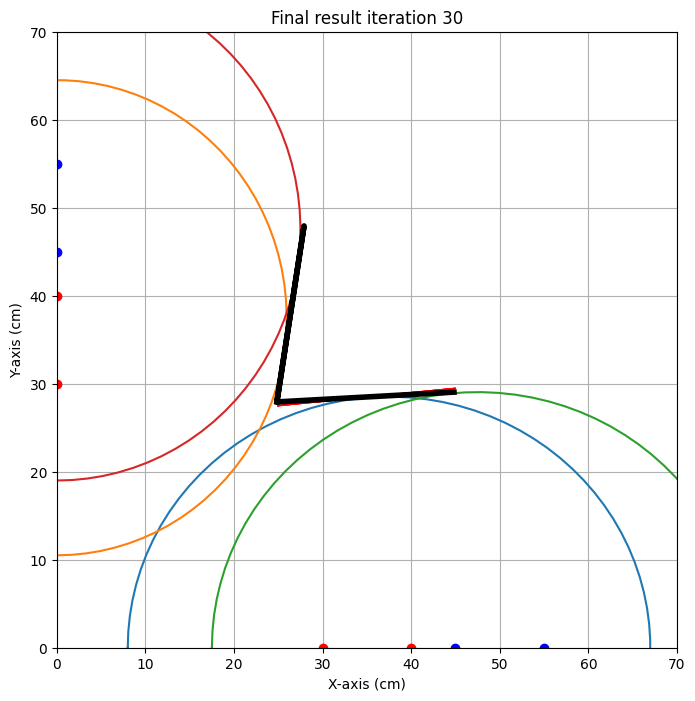

{'alpha': np.float64(3.173654263676399), 'alpha_eps': np.float64(2.433345362351476), 'beta': np.float64(8.72441902193508), 'beta_eps': np.float64(0.8390682089454256), 'x0': np.float64(24.835134572195898), 'x0_eps': np.float64(0.11265858363190873), 'y0': np.float64(27.934027272496355), 'y0_eps': np.float64(0.42689676786409336)}
locatie 1 
x0 target is : 25.7. Gevonden waarde: 24.8 cm met een standaardafwijking van 0.1 cm 
y0 target is : 28.2. Gevonden waarde: 27.9 cm met een standaardafwijking van 0.4 cm 
alpha target is : -5.0. Gevonden waarde: 3.2 graden met een standaardafwijking van 2.4 graad 
beta target is : -5.0. Gevonden waarde: 8.7 graden met een standaardafwijking van 0.8 graad 



In [10]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0': 25.7,
                    'y0'    : 28.2,
                    'alpha' : -5,
                    'beta'  : -5},
            }

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [ 30, 0, 45, 0, 59],
#    [ 50, 0, 65, 0, 240], mis
    [ 0, 30, 0, 45, 54], 
#    [ 0, 50, 0, 65, 240], mis
#    [ 20, 0, 35, 0, 62], hoek 
    [ 40, 0, 55, 0, 60],
#    [ 0, 20, 0, 35, 62], hoek 
    [ 0, 40, 0, 55, 57]
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr   R
0  50   0  65   0  78
1   0  50   0  65  93
2  40   0  55   0  81
3   0  60   0  75  99


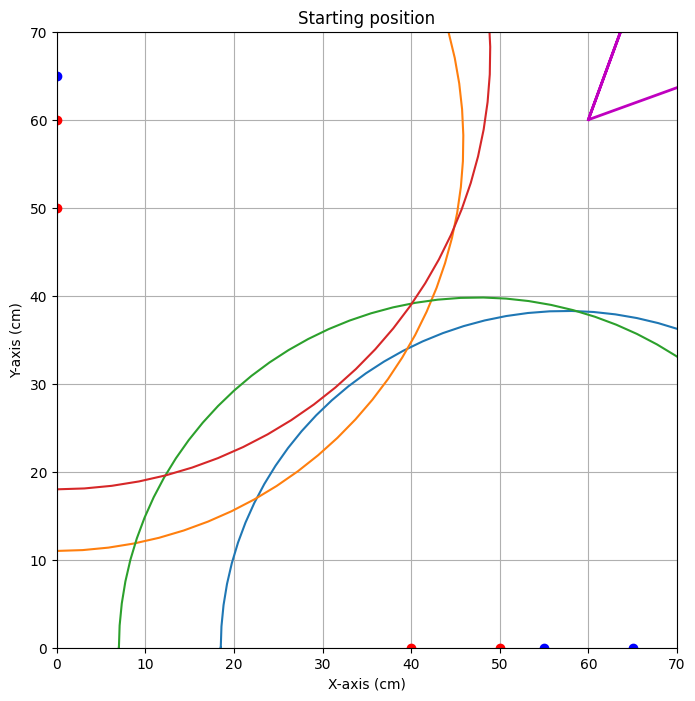


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=39.252


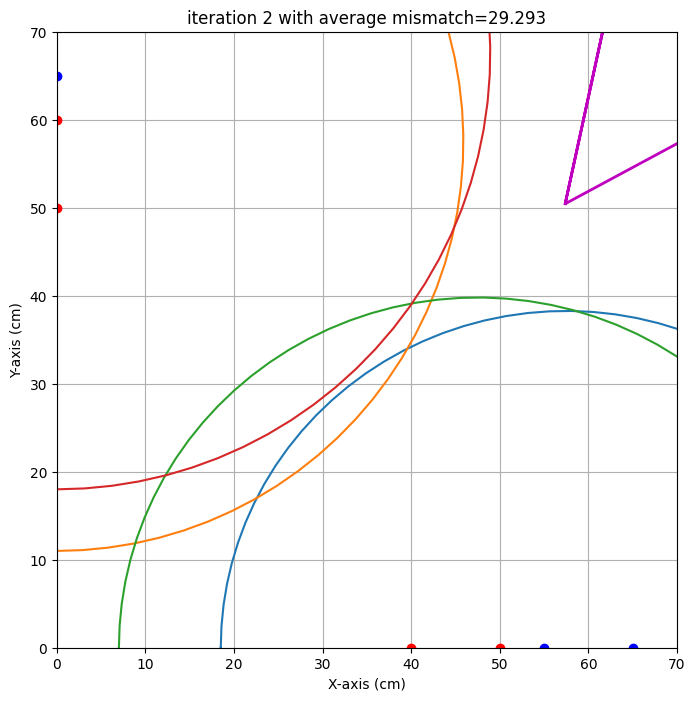

end iteration 2 with average mismatch=29.293


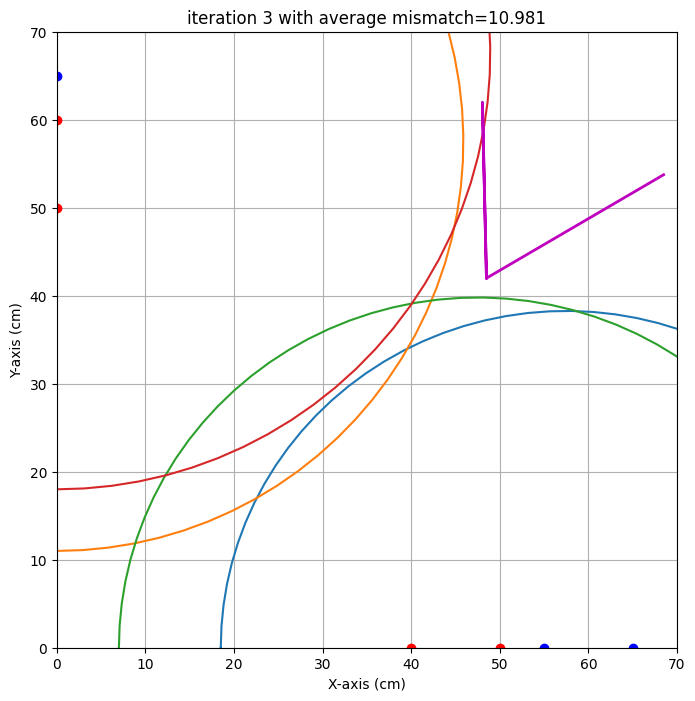

end iteration 3 with average mismatch=10.981


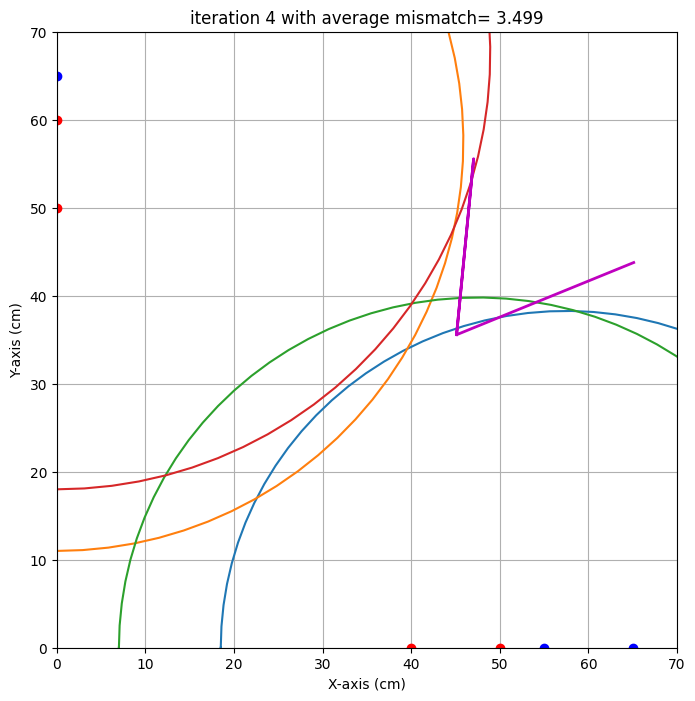

end iteration 4 with average mismatch= 3.499


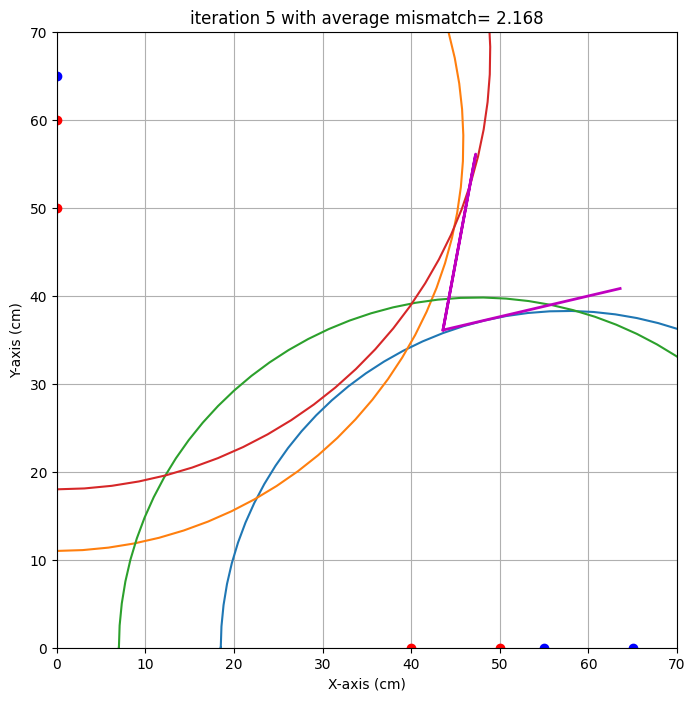

end iteration 5 with average mismatch= 2.168


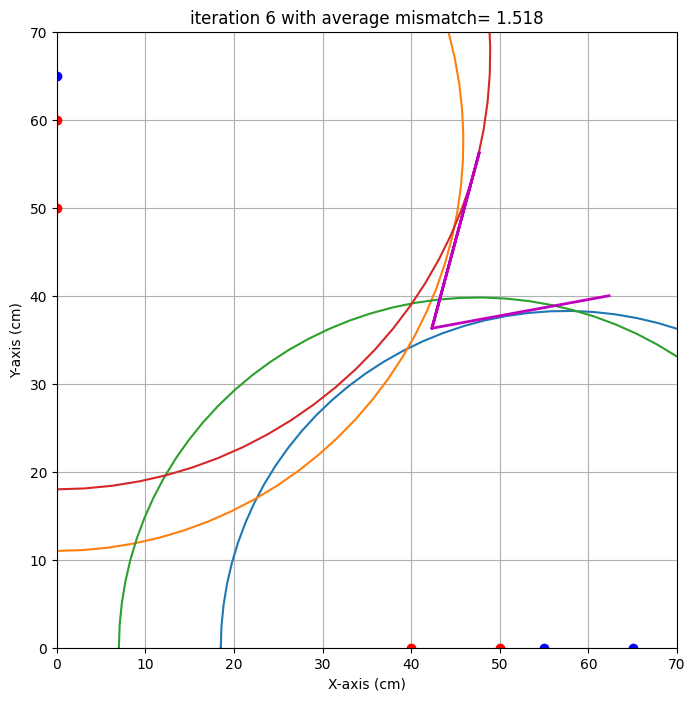

end iteration 6 with average mismatch= 1.518
end iteration 7 with average mismatch= 1.475


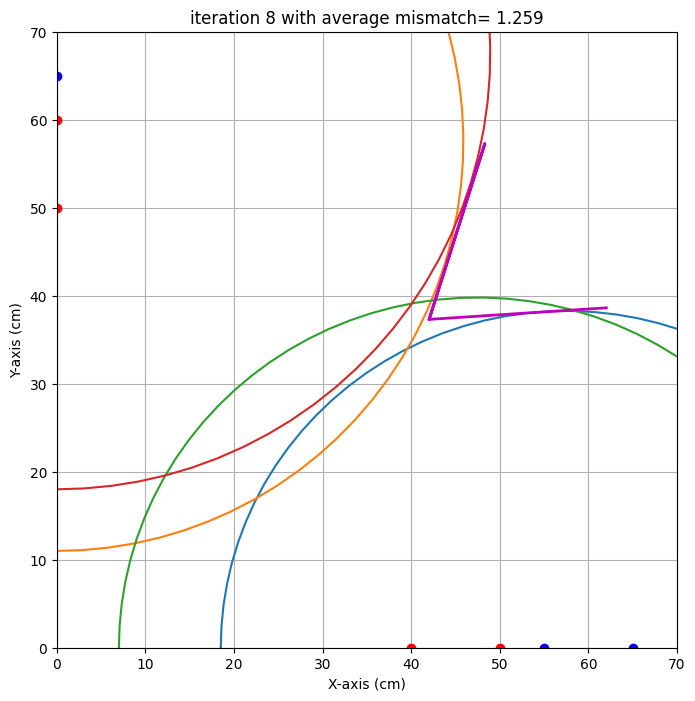

end iteration 8 with average mismatch= 1.259


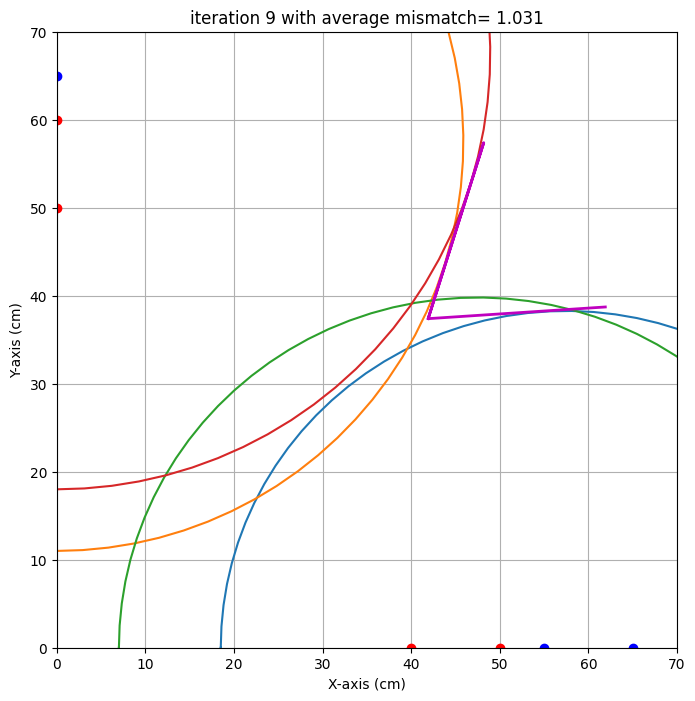

end iteration 9 with average mismatch= 1.031
end iteration 10 with average mismatch= 1.031
end iteration 11 with average mismatch= 1.031
end iteration 12 with average mismatch= 1.031
end iteration 13 with average mismatch= 1.031
end iteration 14 with average mismatch= 1.031
end iteration 15 with average mismatch= 1.031
end iteration 16 with average mismatch= 1.031
end iteration 17 with average mismatch= 1.031
end iteration 18 with average mismatch= 1.028
end iteration 19 with average mismatch= 0.997
end iteration 20 with average mismatch= 0.993
end iteration 21 with average mismatch= 0.993
end iteration 22 with average mismatch= 0.993
end iteration 23 with average mismatch= 0.993
end iteration 24 with average mismatch= 0.993
end iteration 25 with average mismatch= 0.993
end iteration 26 with average mismatch= 0.993
end iteration 27 with average mismatch= 0.993
end iteration 28 with average mismatch= 0.993
end iteration 29 with average mismatch= 0.993
Last iteration, also determine unce

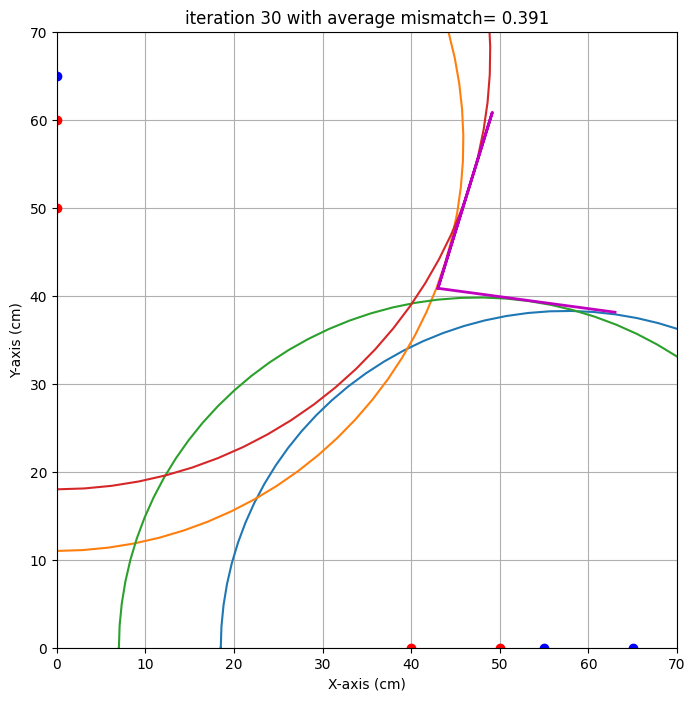

end iteration 30 with average mismatch= 0.391
###############################################################################
end of iteration  30
Best alpha=  -7.74 with uncertainty=   4.25
Best beta =  17.08 with uncertainty=   1.80
Best x0   =  43.02 with uncertainty=   0.78
Best y0   =  40.84 with uncertainty=   1.12
###############################################################################


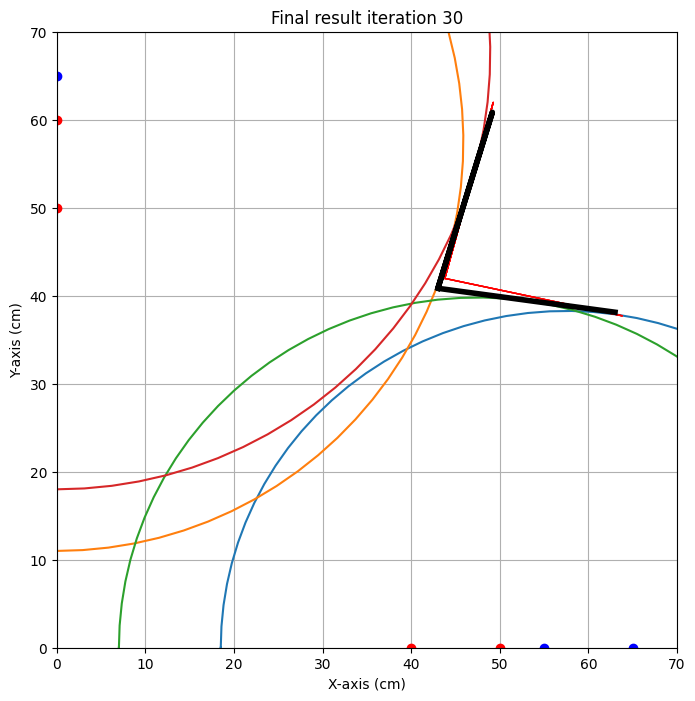

{'alpha': np.float64(-7.738281576701227), 'alpha_eps': np.float64(4.24824717714353), 'beta': np.float64(17.08357838799647), 'beta_eps': np.float64(1.7953978837622238), 'x0': np.float64(43.01507284526855), 'x0_eps': np.float64(0.7808131938282656), 'y0': np.float64(40.843311500388424), 'y0_eps': np.float64(1.1249411099707416)}
test locatie 
x0 target is : 45.6. Gevonden waarde: 43.0 cm met een standaardafwijking van 0.8 cm 
y0 target is : 41.2. Gevonden waarde: 40.8 cm met een standaardafwijking van 1.1 cm 
alpha target is : -10.0. Gevonden waarde: -7.7 graden met een standaardafwijking van 4.2 graad 
beta target is : 17.0. Gevonden waarde: 17.1 graden met een standaardafwijking van 1.8 graad 



In [21]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0'    : 45.6 ,
                    'y0'    : 41.2 ,
                    'alpha' : -10 ,
                    'beta'  : 17 
                          }
            }
           

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
#            [ 30, 0, 45, 0, 170], mis
            [ 50, 0, 65, 0, 78], 
#            [ 0, 30, 0, 45, 240], mis
            [ 0, 50, 0, 65, 93], 
            [ 40, 0, 55, 0, 81],
#            [ 0, 40, 0, 55, 240], mis\
#            [ 0, 60, 0, 75, 99] metinge opnieuw gedaan in overleg met ta
#            [ 0, 60, 0, 75, 100] na later overleg terug naar oude waardes
             [ 0, 60, 0, 75, 99]
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 11: Leerdoelen.

#### algoritme [Bart]
1. start 

2. start met meetlocaties

eerste 4 "test locaties"
om te kijken waar hij ongeveer zit 

bron   , ontvanger
A [30, 0], [40, 0]
B [50, 0], [60, 0]
C [0, 30], [0, 40]
D [0, 50], [0, 60]

    # een meting is ongelding als deze groter dan 70cm of kleiner dan 20cm is

3. maak afhankelijk van welke metingen raakte een keuze voor de volgende metingen

	a (alle 4 raakte)
	 dit betekend dat hij ongeveer in het midden staat en er zijn in principe geen verdere metingen nodig om alles te bepalen


	b (2 raakte: 1 op elke as)
	 dit betekend dat hij in een van de 4 kwadranten zit
	doe 2 extra metingen (1 per as) en verplaats hiervoor alles met 5 richting 0
	in het geval dat een (of allebei)van deze waarde(s) niet geldig zijn verplaats je ze t.o.v hun beginposities 5 van 0 af
	nu zou je 4 goede metingen moeten hebben kan je alles bepalen 


	c (3 raken)
	 dit betekend dat hij in de buurt van een van de randen zit
	doe 1 extra meting op de as waarvan je maar een geldige metingen had en verplaats hiervoor alles met 5 richting 0
	in het geval dat deze waarde niet geldig IS verplaats je hem t.o.v zijn beginposities 5 van 0 af
	nu zou je 4 goede metingen moeten hebben kan je alles bepalen 

	d (1 raakt of 2 op dezelfde as)
	 dit betekend dat de hoek tussen het karton redelijk klein is
	 dit betekend dat hij zich bevind in een van de kolommen tussen of buiten de meetputen A,B,C,D 
	 afhankelijk van op welke as je de metingen had

	als je maar 1 raak is:
		voor de as van de waarde die wel raakte:
		doe 1 extra meting op de as waarvan je maar een geldige metingen had en verplaats hiervoor alles met 5 richting 0
		in het geval dat deze waarde niet geldig IS verplaats je hem t.o.v zijn beginposities 5 van 0 af
		nu zou je 4 goede metingen moeten hebben kan je alles bepalen


	voor de as waar je geen waardes had:
		probeer een van de volgende meetpunten afhankelijk van de as:
		x as
		[20,0],[30,0]
		[40,0],[50,0]
		[60,0],[70,0]
		y as
		[0,20],[0,30]
		[0,40],[0,50]
		[0,60],[0,70]
		
		als deze een raak is:
		doe 1 extra meting en verplaats alles met 5 richting 0
		in het geval dat deze waarde niet geldig is verplaats je hem t.o.v zijn beginposities 5 van 0 af
		nu zou je 4 goede metingen moeten hebben kan je alles bepalen

		als hij mis was:
		kies je een nieuw meetpunt tot i wel raak is

evaluatie: 
het verplaatsen van 5 bleek teweinig te zijn waardoor het pyton programma lasig onderschijd kon maken om een goede lijn te trekken en een voorgorde aangeduid voor de latere punten

Figuur: ![Alt](ideratie_1.png "Title")

evaluatie:
een afstand van 10 cm tussen de dingen bleek te klein te zijn waardoor hij in sommige gevallen niks kon meten 10 -> 15

Figuur: ![Alt](ideratie_2.png "Title")
